# Lesson 183 · Graph-Transformer + pre-training

Implement four evidence contracts, replay every saved prediction, then write a gap brief. Tier B saved F1 evidence and Tier C arithmetic/access fixtures. Default execution is offline and CPU-only. Python3 + NumPy are the only runtime requirements; model source appendices are displayed, not executed. Ask the teacher whenever an assumption is unclear.

<!-- course-portable:start -->
### Follow the computation

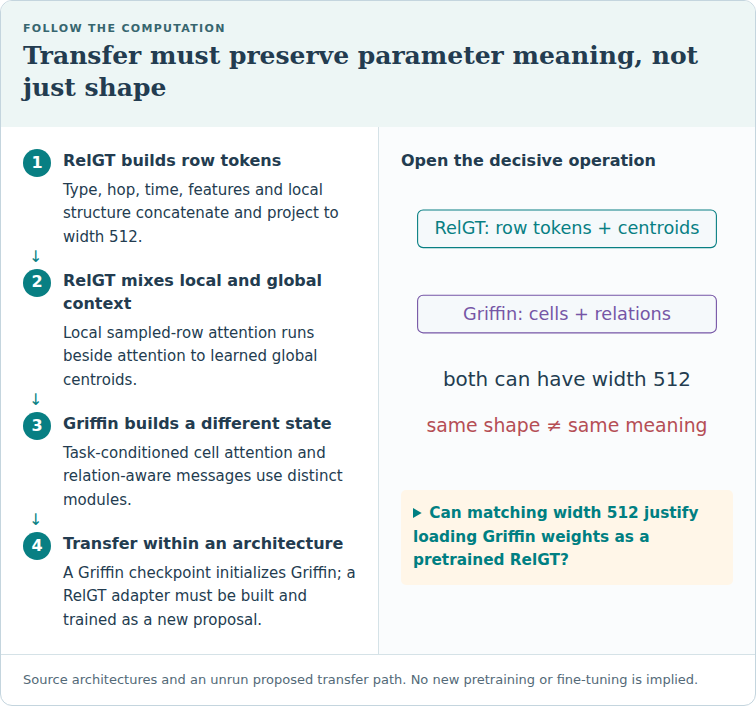

Source architectures and an unrun proposed transfer path. No new pretraining or fine-tuning is implied.

**Trace question:** Can matching width 512 justify loading Griffin weights as a pretrained RelGT?

**Trace answer:** No. Equal tensor widths do not establish that modules or coordinates have the same function.
<!-- course-portable:end -->

In [1]:
# @colab-bootstrap: standalone offline packet; no repository clone or cloud service required.
from pathlib import Path
import json,copy,math
import numpy as np
print("L183: saved predictions and synthetic contracts; new training NOT_RUN; cloud/API $0")

L183: saved predictions and synthetic contracts; new training NOT_RUN; cloud/API $0


**Your win:** turn “combine RelGT and Griffin” into a claim that an experiment could disprove. Trace the inputs that must change, calculate the missing comparison, and write a one-page gap brief. The core reading takes about 15 minutes; use a separate session for the notebook.

**Author evidence:** all **7,554 saved predictions** replayed; four live audit contracts checked. Full published experiments remain **INCOMPLETE**. Fresh model inference, training and hybrid pretraining: **NOT_RUN**. Cloud/API spend: **$0**. Learner: **PENDING_WRITTEN_DEFENSE**.

[Student notebook](https://avistian.github.io/relational/labs/0183-graph-transformer-pretraining.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0183-graph-transformer-pretraining.html) · [Solution download](https://avistian.github.io/relational/labs/solutions/0183-graph-transformer-pretraining.ipynb) · [Quick reference](https://avistian.github.io/relational/reference/graph-transformer-pretraining.html) · [Full reproduction contract](https://avistian.github.io/relational/labs/l183-reproduction.md).

## 1 · The next question is about learning before the target task

[Lesson 145](https://avistian.github.io/relational/lessons/0145-relational-graph-transformer.html) introduced RelGT's graph tokens. [Lesson 146](https://avistian.github.io/relational/lessons/0146-gnn-vs-graph-transformer.html) compared a reduced RelGT with a course GNN. [Lesson 164](https://avistian.github.io/relational/lessons/0164-griffin-graph-centric-rdb-fm.html) examined Griffin's pretrained initialization. We now ask whether pretraining changes the relative value of these backbones. A **backbone** is the central network that transforms encoded inputs into representations used for prediction.

**Pretraining** fits weights on source tasks before the target task. **Fine-tuning** updates those weights using target-task training labels. A **scratch control** starts from random weights. These are different starting conditions for training, not different names for inference.

This advances our mission: an architecture idea becomes useful when we can explain its mechanism and test its incremental value. [Lesson 182](https://avistian.github.io/relational/lessons/0182-rdb-pfn-composite-message-passing.html) practices architecture-combination hypotheses. Here we focus on the extra effect of pretraining; no earlier hypothesis is assumed to have succeeded. Earlier practical exits and learner mastery remain unchanged.

## 2 · First narrow the gap

A tempting claim is “relational graph transformers have never been pretrained.” Do not use it. The authors' research overview already connects this architecture family to KumoRFM. A search that finds no exact combination also cannot establish novelty. [Primary research overview](https://docs.nvidia.com/sdgm/research/relational-graph-transformers)

Our narrower question is: **with a shared input interface and matched target supervision, does source pretraining benefit a RelGT-style backbone more than a message-passing backbone?** This is a proposed experiment. We have not established that it is a novel research contribution.

> **In plain terms.** Compare what each model gains from prior practice. Comparing two already different systems once cannot tell you why one wins.

Read [RelGT §3](https://arxiv.org/html/2505.10960v1#S3) alongside [Griffin §3](https://arxiv.org/html/2505.05568v1#S3). Read for interfaces: what enters each block, which parameters depend on the schema, and what a prediction means. A **schema** specifies tables, columns and their relationships.

## 3 · Model architecture: what would actually transfer?

### RelGT: five descriptions of each row

A query contains an entity and a cutoff time. A **foreign key** links one table's row to another table's entity. Sampling follows those links to collect a bounded neighborhood. Each row receives five descriptions: its features, table type, hop distance from the query, relative time, and local graph structure. A hop is one traversed link. Structural encoding uses a small GNN on the sampled graph.

The release encodes each description into a vector, concatenates them, and projects the concatenation to the model width. **Attention** computes weighted combinations of representations. RelGT combines local token attention with a global branch attending to learned centroids; centroids summarize patterns rather than representing every database row explicitly. The head maps a representation to a task prediction. [Paper §3](https://arxiv.org/html/2505.10960v1#S3), [retained implementation](https://avistian.github.io/relational/labs/relkit/relgt_l145.py).

**Read the operations.** An embedding is a vector of learned or encoded numbers. Concatenation places vectors side by side; projection mixes their coordinates into a chosen width. A GNN (graph neural network) updates a row vector using linked rows. Attention compares query and key vectors, turns their scores into weights that sum to one, then combines value vectors. These attention queries are internal vectors, distinct from the database prediction query.

<figure class="route-figure" tabindex="0">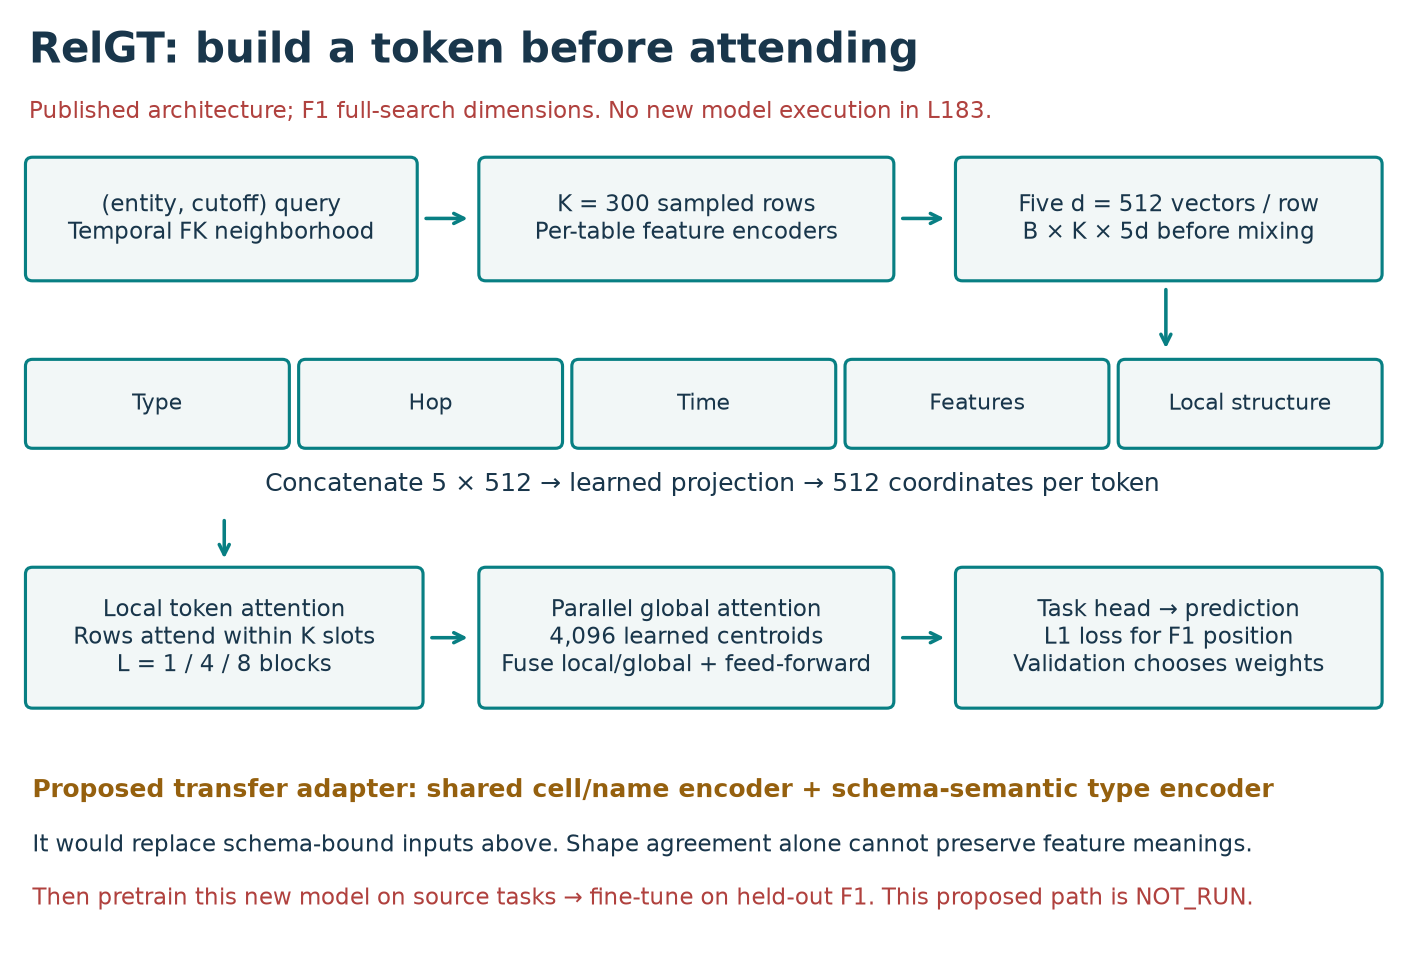<figcaption>RelGT source architecture and proposed schema adapter. B is batch size; K is row-token count; d is vector width. Local and global branches are fused inside each block. Model dimensions are the full F1 search, not the reduced saved course runs.</figcaption></figure>

**The interface problem.** The released feature encoders are allocated per table, and table types have indexed embeddings. On a new schema, index 0 might mean a patient rather than a driver. Matching a vector's width does not preserve its meaning. A transferable variant needs a defined shared cell/name encoder and a schema-semantic replacement for table IDs. That is new engineering, not a proven consequence of tokenization.

**Worked example.** Suppose a frozen type registry uses drivers = 0 and races = 1. A new registry reverses those IDs. Looking up driver ID 1 now returns the old race vector. Both vectors still have the right width. Aligning existing names can fix this permutation; handling an unseen patient table needs an additional semantic rule. The notebook checks this small counterexample explicitly.

### Griffin: ask the cells a task-specific question

Griffin encodes cells and metadata into a common space. Metadata includes column names and relation descriptions. The target column supplies a task representation. Task-conditioned cross-attention selects information from each row's cells; message passing exchanges information along graph relations. Its shared decoder converts the target-row representation into an answer. The paper distinguishes fixed numerical encoder/decoder components from the learned relational model. [Griffin §§3.1–3.3](https://arxiv.org/html/2505.05568v1#S3), [released model](https://avistian.github.io/relational/labs/sources/l164/upstream/hmodel.py).

**Read the conditioning.** Cross-attention forms its query from the current row state and target-task representation. Its keys describe column metadata; its values encode the cells. Thus the same row can be summarized differently for different target columns. A shared decoder reuses the same learned output rule across those tasks.

<figure class="route-figure" tabindex="0">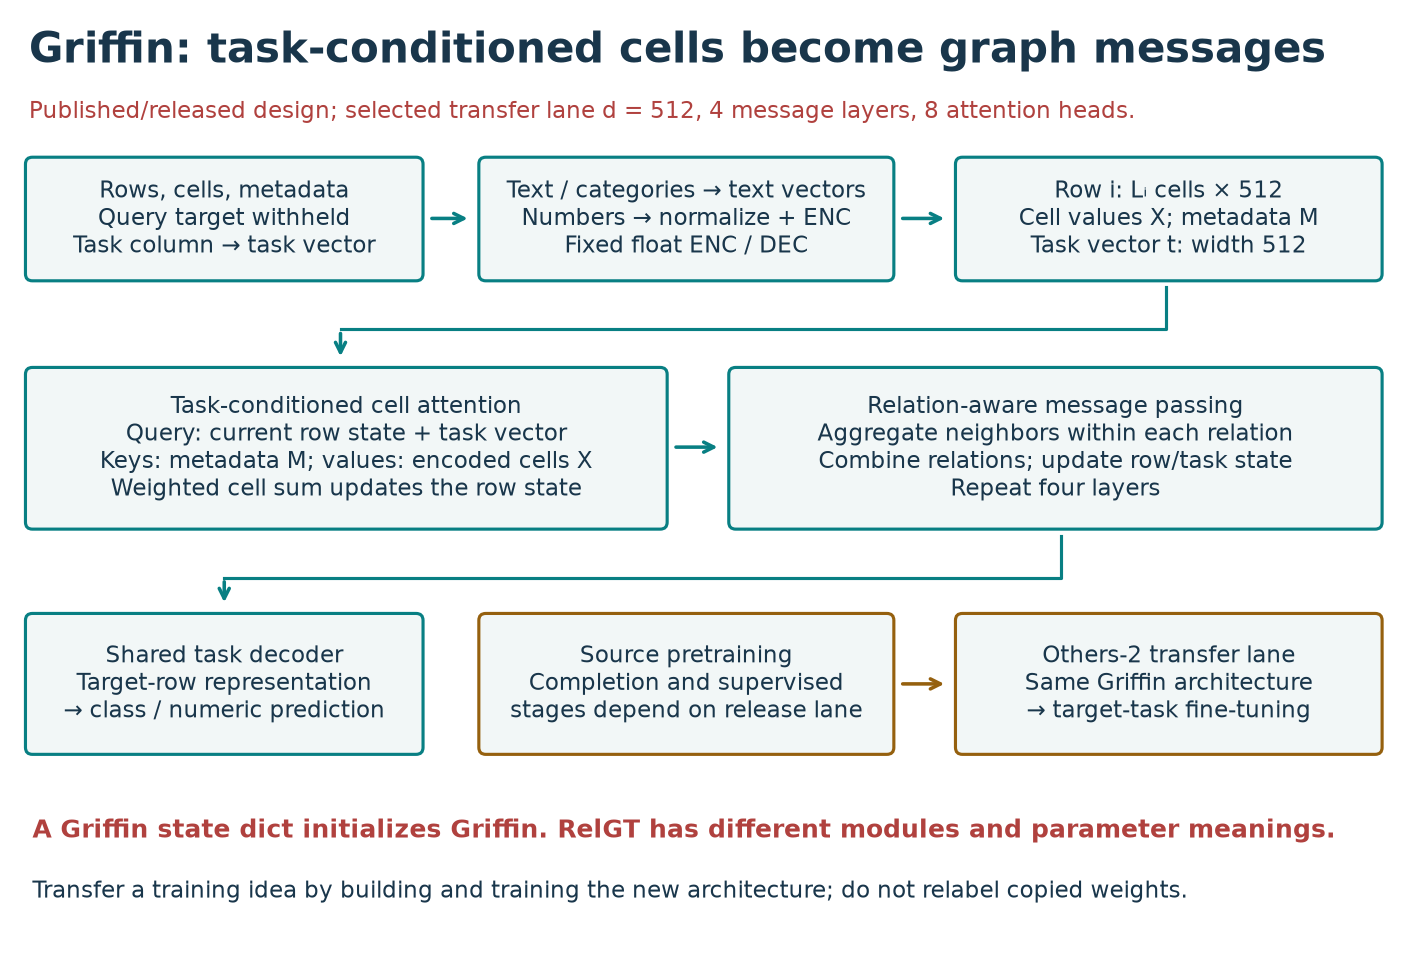<figcaption>Griffin source/release pathway: cell encoders, metadata/task attention, relation-aware messages and shared decoding. Lᵢ counts cells in row i. Pretraining initializes the same architecture before target fine-tuning; it does not produce RelGT-compatible weights.</figcaption></figure>

**A training recipe is not a checkpoint adapter.** A checkpoint is a collection of learned parameter tensors. Griffin and RelGT have different modules and parameter meanings. Loading Griffin weights into a RelGT-shaped network is not the proposed experiment. We would build the new shared-interface model, pretrain its own parameters, and compare it with its own scratch control. The released Griffin code also contains operations beyond the compact paper equations; the notebook retains both the visible model and original trainer.

**Risks to name:** incompatible schema semantics, different cell-versus-row representations, task loss weighting, negative transfer, temporal contamination, and higher compute. **Negative transfer** means the pretrained initialization makes the target result worse than scratch under the declared protocol.

## 4 · Withhold unavailable information, not just the query answer

Masking replaces a target value with an unavailable marker. It does not remove future neighbor rows, late-arriving features or labels whose outcome windows have not finished.

**Worked example.** At cutoff 10, a feature from time 5 arriving at time 6 is visible. A label anchored at 5 whose window ends at 12 is unavailable. A future event at 12 fails our strict event-time rule even if someone published its schedule at 6. Unknown arrival time also fails this strict admission rule; that is missing evidence, not proof of leakage.

<figure class="route-figure" tabindex="0">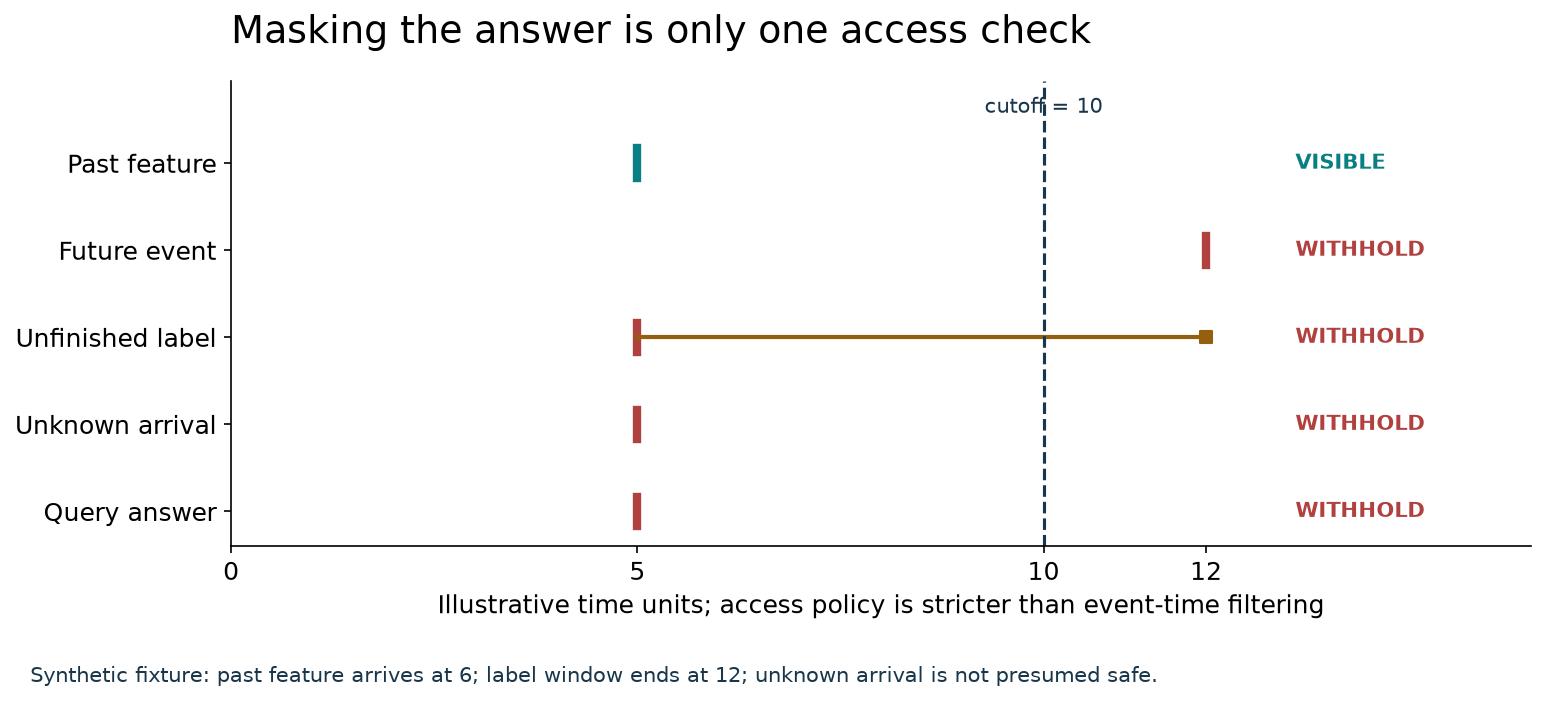<figcaption>Synthetic cutoff-10 policy fixture. Only the past feature passes every access rule. The query target, unknown arrival, future event and unfinished outcome window are all withheld for different reasons.</figcaption></figure>

Your first notebook function implements this policy. It requires known event and arrival times no later than the cutoff, completed label windows, and a withheld query target. The fixture uses invented time units. It is stricter than some source protocols and is not a correction silently applied to a paper result.

**Real inherited warning.** L145's saved audit reports 569,502 future-token occurrences in training and 21,368 in validation. L183 authenticates that report and checks a saved violating witness. It does **not** rescan the full token cache. Fixing the context construction creates a separately declared experiment. [Original reproduction contract](https://avistian.github.io/relational/labs/l145-reproduction.md).

## 5 · What the existing evidence does—and does not—answer

Predict before reading: if RelGT won validation in all three pairs, must it win test? Write your answer before continuing.

The lab replays all six L146 course fits: two backbones × three seeds, each with 499 validation and 760 test predictions. It joins predictions by **(entity, cutoff)**, verifies saved target values, checks complete ten-epoch histories and validation-selected epochs, and independently recomputes mean absolute error. **MAE** is the average absolute distance between prediction and target; lower is better.

| Saved course arm | Validation MAE, mean ± seed SD | Test MAE, mean ± seed SD |
|---|---:|---:|
| Course GNN | 3.197652 ± 0.056532 | 4.293632 ± 0.037816 |
| Reduced RelGT | 3.048312 ± 0.102734 | 4.617536 ± 0.291141 |


<figure class="route-figure" tabindex="0">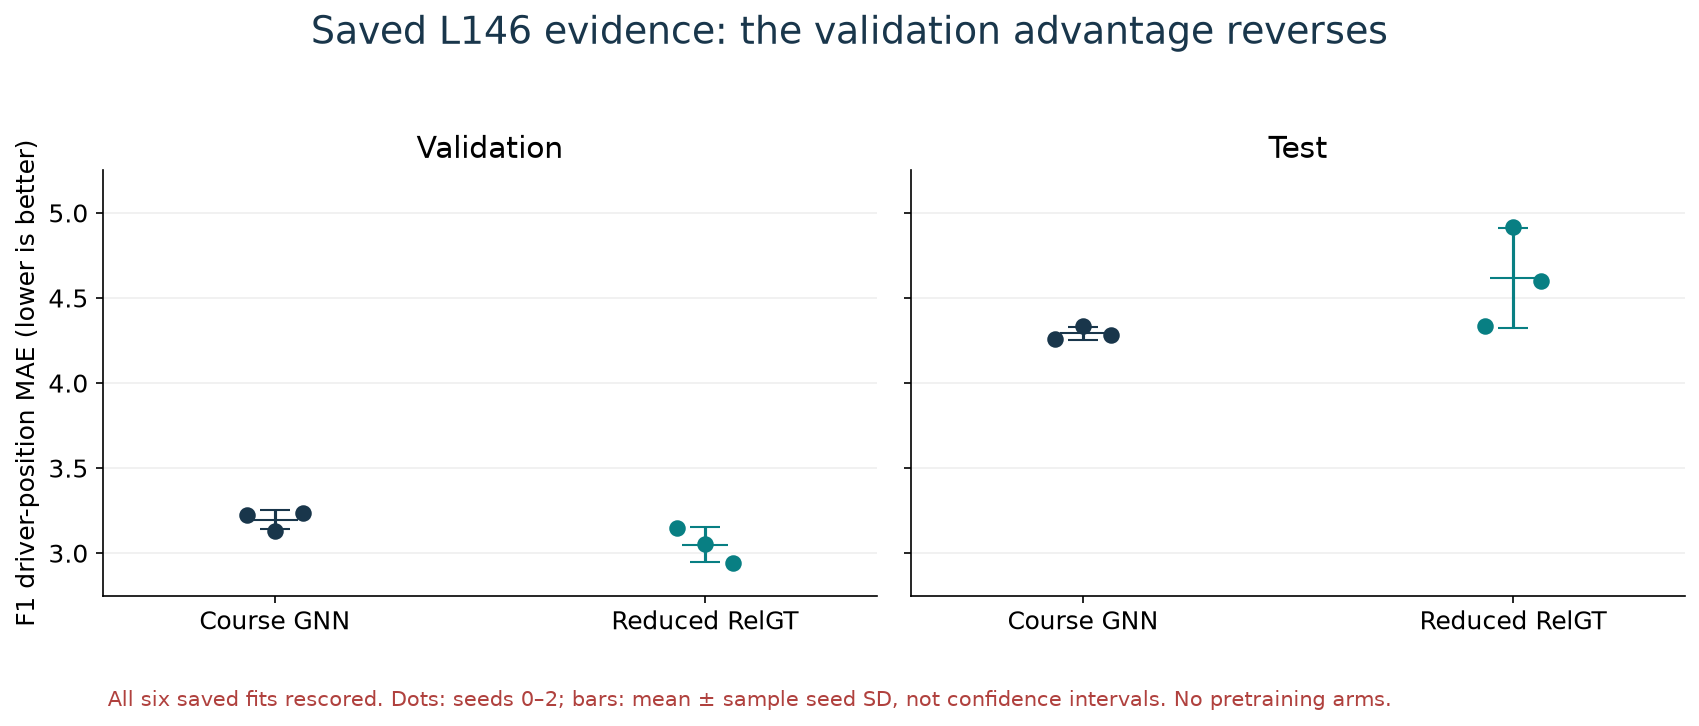<figcaption>Six saved L146 course runs, freshly rescored on complete query keys. Dots show three seed scores; error bars show mean plus/minus sample seed standard deviation, not confidence intervals. Both arms start from scratch.</figcaption></figure>

These runs used full query populations but reduced course architectures and a ten-epoch recipe. The GNN has lower test MAE in all three seed pairs; RelGT has lower validation MAE in all three. Equal seed labels do not create identical initial weights. Differences in encoders, readout and compute remain. This compares complete designs under a common recipe, not the isolated effect of attention.

> **Scope check.** The 7,554 predictions are saved evidence, freshly rescored. No new weights or predictions are produced. Raw labels are matched to the saved preparation, not reconstructed from database SQL again. Neither arm was pretrained. This comparison cannot estimate a pretraining benefit, and its already-seen test population is exploratory evidence. [L146 protocol](https://avistian.github.io/relational/labs/l146-reproduction.md).

## 6 · The missing experiment has four arms

A **factorial experiment** varies two factors together. Here they are backbone (message passing or graph transformer) and initialization (scratch or pretrained). All four combinations are needed to ask whether the benefit of pretraining depends on the backbone.

**Worked example — invented values.** Message-passing MAE falls from 4.0 to 3.6: gain 0.4. Transformer MAE falls from 3.9 to 3.2: gain 0.7. The extra benefit is 0.7 − 0.4 = **+0.3**. This difference of gains is the **interaction**. For a higher-is-better metric such as AUROC, calculate each gain as pretrained minus scratch instead.

<figure class="route-figure" tabindex="0">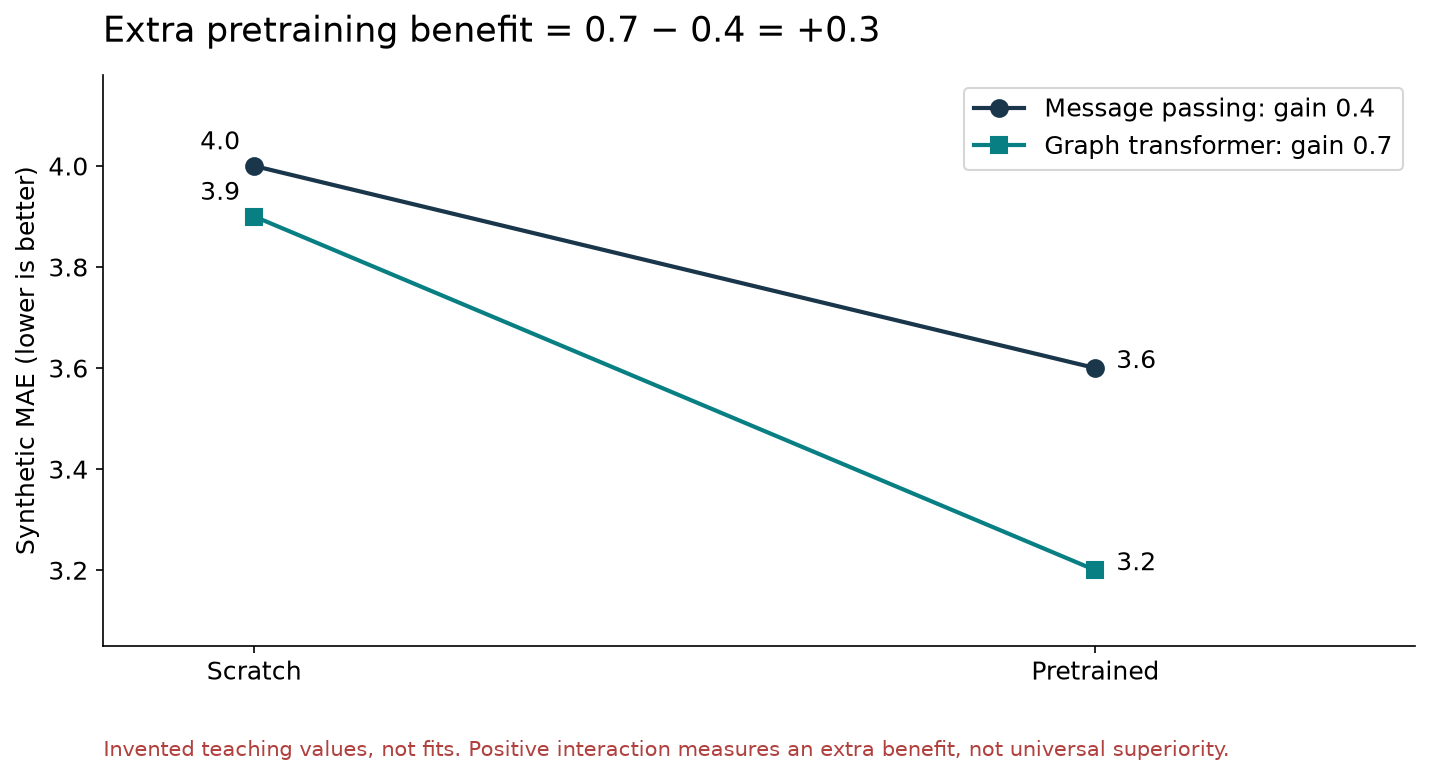<figcaption>Invented single-seed MAE values. MP gain 0.4; GT gain 0.7; extra GT benefit +0.3. These values illustrate arithmetic and are not trained-model evidence.</figcaption></figure>

Notebook intervention: change only GT pretrained MAE to 3.5 and predict the interaction; then run the TRY cell below.

A positive interaction does not require the pretrained transformer to be the best model. It could improve more from a much worse starting point. Conversely, a transformer can win both comparisons while gaining exactly as much from pretraining as message passing. Keep the absolute scores alongside the contrast.

**A positive interaction can coexist with negative transfer.** In this invented counterexample, lower MAE is better:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Backbone</th><th>Scratch</th><th>Pretrained</th><th>Gain</th></tr></thead><tbody><tr><td>Message passing</td><td>4.0</td><td>5.0</td><td>−1.0</td></tr><tr><td>Graph transformer</td><td>4.0</td><td>4.5</td><td>−0.5</td></tr></tbody></table>

The interaction is `−0.5 − (−1.0) = +0.5`. Pretraining hurt both backbones; it merely hurt the transformer less. Report each gain before interpreting their difference. **Transfer check:** if both pretrained MAEs are instead 3.0, each gain is +1.0 and the interaction is zero. Useful pretraining does not require a nonzero interaction. The notebook requires at least two matched seed blocks; repeating these invented numbers tests the arithmetic, not uncertainty.

### A concrete probe brief, awaiting a separate execution protocol

Use `rel-f1/driver-dnf` as a **single-database feasibility probe**, with 512 and 4,096 target labels, subset seeds 42–46, and all 566 validation / 702 test queries in the pinned Griffin release. Four arms × two label budgets × five seed blocks gives **40 target fits**. The pretrained arms require their own source-training runs; those costs cannot disappear from the budget.

The initial source-task candidate is the [pinned release's Others-2 group](https://avistian.github.io/relational/labs/sources/l164/upstream/task_names.yaml): Airbnb destination, three trial tasks, TalkingData demographic prediction, and Telstra severity. Authenticate its exact data and exclude all F1 rows, edges, labels and fitted statistics from every source-training stage before use. It is a candidate corpus, not a newly audited pretraining lineage. Fix shared input semantics, decoder, loss weighting, permissible neighborhoods, parameter budget and selection policy before running. Initialize source training independently for each backbone; do not copy Griffin weights into RelGT. Match target subsets and validation policy across all four arms. Document both training-example exposure and compute—equal epochs alone do not equalize them.

**Primary contrast:** extra pretraining gain in target AUROC, computed within each seed block and label budget. **Falsification:** nonpositive transformer pretraining gain undermines the transfer-benefit claim; nonpositive interaction undermines the extra-benefit claim. Report every arm and seed, including failures. With only one target database, a positive result justifies a later study holding out entire databases; it does not demonstrate general cross-database superiority. Paired seed spread is not uncertainty over databases.

> **Scope check.** Source schedule, adapter implementation, corpus availability, selection details and an all-in cost bound still need to be frozen and approved. This brief is not an executable training protocol. All 40 proposed fits and new source pretraining are **NOT_RUN**. The runnable notebook verifies the design's evidence contracts and arithmetic.

## 7 · Keep the full published experiments intact

| Named experiment | Retained complete scope | Current boundary |
|---|---|---|
| RelGT v1, F1 driver-position, Tables 1/6 | Nine depth/dropout configurations; 100 epochs each; original width, context and training recipe | Temporal gate fails; inherited shallow-speed forecast $80.41 before final evaluation/overhead |
| Griffin v1, Table 12, Others-2 → F1 driver-dnf | Two initialization arms × two label budgets × five subset seeds; full source schedule and evaluation | Inherited conservative forecast $63.89 adjusted compute; 20 full fits unrun |
| L146 course comparison | Six saved fits; all 7,554 held-out predictions | Complete saved-prediction replay; no pretraining comparison |
| Proposed hybrid | Four-arm probe above | New architecture and source pretraining NOT_RUN |

The $10 lesson ceiling includes preparation, retries and validation. L183 spends $0 on cloud/API work and caps aggregate local numerical execution at 3,600 seconds. Its paper forecasts use inherited rates and timings; they are not current quotes or invoices. We do not pay for another pilot merely to rediscover existing blockers. The [full contract](https://avistian.github.io/relational/labs/l183-reproduction.md) retains source revisions, exact commands, paper targets and deviations. Local admission commands refuse training while those gates remain unresolved.

## 8 · Your deliverable: a gap brief that can lose

Complete the four notebook functions. Then write one page with: the narrow claim; the source-to-target interface; the four arms; what is held fixed; permitted information; validation selection; the two falsification criteria; full cost accounting; and the result that would make you abandon the idea.

Write the one-page brief in the EXIT cell and ask the teacher for review.

**Return tomorrow:** without notes, draw the four-arm table and explain why comparing only pretrained Griffin against scratch RelGT is confounded. A week later, write a negative-transfer example and explain its interaction sign. Ask the teacher follow-up questions or paste your brief for review. Author preparation does not establish your mastery.

**Next: [Lesson 184](https://avistian.github.io/relational/lessons/0184-gelgt-temporal-attention.html).** Before proposing more pretraining, trace how one downstream model admits context, selects distant rows, and weights time. Those are three separate decisions in GelGT.


## PROVIDED · Authenticate and unpack the evidence
The archive includes every saved prediction and the retained model/trainer sources. The fixed manifest checks each file before analysis. Hashes establish byte identity, not historical legality.

In [2]:
import base64,hashlib,io,zipfile
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='9c2def76a47198da22c31910391d9a93d32d521024acc1eeceead19747f90c0d'
P=Path('l183-packet');P.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(P)
manifest={'files': {'labs/evidence/l146/summary.json': '6d3f4ea149d6644bd8d3e3a1a27f0894e5c95229aa6682c51ac120df2a6df54c', 'labs/evidence/l146/paper-table.json': 'a38b5bf8b45853633e6f0f75f16bd85c2450bcde11a1822c1bf508fa1fc1fde8', 'labs/evidence/l146/sources.json': 'e396d68cb6625c434ac9eff318587e4e135ac2edfbbaedc1817891928eb3b0ce', 'labs/evidence/l145/prepared/audit.json': '00f3e6b0e48d22104116110293549132e78873d65ee9a1bd59039f6134a2b2f6', 'labs/evidence/l145/cost-decision.json': '3fbaa1e35816d79dc21acecc23cdc4d2d08b4206bc77222a9f46554b575669e7', 'labs/evidence/l164/cost-decision.json': 'aa3e7e7c61ccbc233fcc54647410c62e514bf6e9c280c0dcc024039080a9239d', 'labs/evidence/l164/pilot.json': '74c1328f161de40f8224babfc6d6b7e1f9e7c3682dddbda55402acc114a8a62b', 'labs/evidence/l164/source-audit.json': 'c2f86295f16127de011b9346ca531488a9ad9b625a99505095248f5ff70421c6', 'labs/evidence/l164/delivery-manifest.json': '1ff03ee447420c4d336f21d1e26d9be4000be7ddc258c5ca672871f82d041760', 'labs/l145-reproduction.md': 'c3d0b22321fa3db48f9391261e84d368961dca8e34c7189446532b6f263bff09', 'labs/l146-reproduction.md': 'efdcfcfe884ece5e040f319d168012945d5744241e3b7c26ce3fe62e29906655', 'labs/l164-reproduction.md': '530d0d692cfbfdf968979efdf848518dd0829bd470f7eadeaaded0ff4217117d', 'labs/relkit/relgt_l145.py': 'fed312df24a26e65caed272c64a86cc67c959e065284db1b6556979a1df700f5', 'labs/_full_l145.py': '49ab42e89660fd7a15f6776afcbdfbc0c144ee5817fe7dd8e0f7dad7b9d72368', 'labs/relkit/griffin_l164.py': '5d95f8dde2a771132793076e7dfa86fb5779df2602d272a1a0a452dab4a5e1c0', 'labs/_run_l164.py': 'a29c00b40305a2e5fcee93532635bbb34a4a4510c99c7b2dc714166fcbf192ce', 'labs/sources/l164/upstream/hmodel.py': '8f72abb348e86e4f32ab727729aa1a8230eab813f5363b9ef73cd2f61b67b965', 'labs/sources/l164/upstream/hmaintask_downsample_absolute_eval_sample.py': '5009a787419db3c8abf2cc521df3b4d147882edfa7493ac1c2ff03994c8c7226', 'labs/sources/l164/upstream/LICENSE': 'bd837f9a2ce9de0682847b4c4c4588dea47710716105d2f60632e06c2c7b1400', 'labs/sources/l145/LICENSE': '902946074382104c702b9e328d7b395c4398ca666b86d194e36f9cf326d1f087', 'labs/sources/l165/paper.txt': '3c5cfedc7eaf852d225fbe995dbaa898072ec21eba340e5b8a057e9af273eaa0', 'labs/sources/l165/source-ledger.json': '41dc3667b8c9ea0bb6d03723e0fb88ec041736d220b4593fbe333ece5af364f4', 'labs/evidence/l146/fit-gnn-0/predictions.npz': '126839047ebb334f0b09af8dae0619c20e2e16d6ee26ac18fbecf5cc9861a8d9', 'labs/evidence/l146/fit-gnn-0/result.json': '2cd96b676212dd1187e90ac96bff25da85894d2621bd21bebb25768609ca359d', 'labs/evidence/l146/fit-gnn-1/predictions.npz': '35c395ef3f74bdd00f31cd16a2010df934155cd387dec814850d9e3907cdd59e', 'labs/evidence/l146/fit-gnn-1/result.json': 'f95472e132dada13ef6ce3b70d5ce9e673116ff4f9b9962934ae559e48b1c3ab', 'labs/evidence/l146/fit-gnn-2/predictions.npz': '2e5a8e4e32f0ef1ba533c7c970b0102589c2767bfaa40e9ef73e918c80bf1ec1', 'labs/evidence/l146/fit-gnn-2/result.json': '3f476ba14e72dda049b970b6779951ab28483b33c8dbe29f95bd37f3795bdb70', 'labs/evidence/l146/fit-relgt-0/predictions.npz': 'f952191c3d2488f9d35c3d010e8ddbf21a187c3f43ddb1e94c2cf2836f2439a6', 'labs/evidence/l146/fit-relgt-0/result.json': '742840a54e6075ac5ee26e8b6b4d1fcb21e04ee30e7044a8f37ea2dea5cd8340', 'labs/evidence/l146/fit-relgt-1/predictions.npz': 'dcc05ae9a2f3195c1a550bdc79e489977d5273cc56bc889581d2aad9c6660796', 'labs/evidence/l146/fit-relgt-1/result.json': 'd3b25eaf14bef74021a6d4d2a357542ed7a30a8c043626316cc036a9923670af', 'labs/evidence/l146/fit-relgt-2/predictions.npz': '798d1fa83128d8b4f7afcbbaec2ff408b992af3303f8fa3b742ddcb7797eb9ea', 'labs/evidence/l146/fit-relgt-2/result.json': '6fd609ed7892a95096901f0e0b6db48985a88ba2903a631961fd08cfed54ffd8', 'labs/sources/l164/upstream/task_names.yaml': '41d8fc0ec240aa75215a0805fa78b20c22a09e6233cfd1b644c90f09e6080f48', 'labs/evidence/l164/budget.json': '21679a43f148c4d92e198d87b44c6d7c30ebef6029bff6222762e2f4b104cd51', 'labs/evidence/l145/pilot-1/result.json': '97d478cea826642bb64c049ec4c6551e727526db5fd3ee8a94835d27a2626602', 'labs/evidence/l146/prepared/val.npz': '18112d6f50cbbf11c0ddf13c2f242c8a5d19d36a44e42523f96faf4e63eac26f', 'labs/evidence/l146/prepared/test.npz': '69f2f8f519337b411fa00d12be565d254369dd73bbe2a77bb3c2f714e187133d'}, 'inherited_commit': 'a19d8720bbcf84d1d36a59cac6130a1bc3a12a22', 'authentication': 'Byte equality with Git HEAD; canonical model/trainer hashes also match original lesson ledgers', 'boundary': 'Saved evidence only; raw database labels, full token caches and model weights are not rerun or reauthenticated here'}
print('Authenticated packet:',len(manifest['files']),'files')

Authenticated packet: 39 files


## TODO · Separate four access rules
Input: a list of cell dictionaries and a numeric cutoff. Required fields are event_time, available_at, is_label, label_end, query_target. Flags must be actual booleans; times must be finite numbers or None. Reject missing fields and label windows ending before their event time. Return one boolean per cell: require known event/arrival no later than cutoff; labels also need a known completed window; query targets are never visible. Unknown time means withhold, not proof of leakage.

In [3]:
def temporal_mask(cells, cutoff):
    """Strict course policy; unknown event/arrival times deny access, not prove leakage."""
    import math
    if isinstance(cutoff, bool) or not isinstance(cutoff, (int,float)) or not math.isfinite(cutoff):
        raise ValueError('Finite numeric cutoff required')
    visible=[]
    for cell in cells:
        required={'event_time','available_at','is_label','label_end','query_target'}
        if not required <= cell.keys(): raise ValueError('Missing access metadata')
        if type(cell['is_label']) is not bool or type(cell['query_target']) is not bool:
            raise ValueError('Flags must be boolean')
        for name in ['event_time','available_at','label_end']:
            value=cell[name]
            if value is not None and (isinstance(value,bool) or not isinstance(value,(int,float)) or not math.isfinite(value)):
                raise ValueError('Times must be finite numbers or None')
        event,arrival,end=cell['event_time'],cell['available_at'],cell['label_end']
        if cell['is_label'] and event is not None and end is not None and end<event:
            raise ValueError('Label window ends before its reference time')
        allowed=event is not None and arrival is not None and event<=cutoff and arrival<=cutoff
        if cell['is_label']: allowed=allowed and end is not None and end<=cutoff
        visible.append(bool(allowed and not cell['query_target']))
    return visible

### CHECK · Use your function

In [4]:
c=dict(event_time=5,available_at=6,is_label=True,label_end=12,query_target=False)
assert temporal_mask([c,dict(c,label_end=10)],10)==[False,True]
print('CHECK: horizon boundary distinguishes two otherwise identical cells')

CHECK: horizon boundary distinguishes two otherwise identical cells


## TODO · Score complete query populations
Input rows are (entity, cutoff, value). Reject duplicates in either side, empty populations, nonfinite values and different key sets. Return mean absolute error after aligning complete keys; row order is irrelevant. A driver may occur at several cutoffs.

In [5]:
def keyed_mae(reference, predictions):
    """One finite target/prediction per (entity, cutoff); exact population equality."""
    import math
    def index(rows):
        out={}
        for entity,cutoff,value in rows:
            key=(entity,cutoff)
            if key in out: raise ValueError('Duplicate query key')
            if not math.isfinite(float(value)): raise ValueError('Nonfinite value')
            out[key]=float(value)
        if not out: raise ValueError('Empty population')
        return out
    truth,pred=index(reference),index(predictions)
    if truth.keys()!=pred.keys(): raise ValueError('Query populations differ')
    return math.fsum(abs(value-pred[key]) for key,value in truth.items())/len(truth)

### CHECK · Use your function

In [6]:
assert keyed_mae([(7,10,2.),(7,20,5.)],[(7,20,3.),(7,10,2.)])==1.
print('CHECK: repeated entity and reordered cutoff rows align')

CHECK: repeated entity and reordered cutoff rows align


## TODO · Calculate the extra pretraining benefit
Require exactly mp_scratch, mp_pretrained, gt_scratch and gt_pretrained, each mapping seed IDs to finite scores. Require identical seed sets and at least two seeds. higher_is_better must be boolean. Return seeds (sorted), mp_gain_mean, gt_gain_mean, interaction_per_seed, interaction_mean, interaction_sample_sd. Gains are improvements in the metric direction; interaction is GT gain minus MP gain. Sample SD uses n−1. Do not pool different tasks or metric units.

In [7]:
def factorial_effect(arms, higher_is_better=False):
    """Matched seed blocks; positive interaction means extra pretraining benefit for GT."""
    import math,statistics
    required={'mp_scratch','mp_pretrained','gt_scratch','gt_pretrained'}
    if set(arms)!=required or type(higher_is_better) is not bool:
        raise ValueError('Exactly four arms and a boolean metric direction required')
    seeds=set(arms['mp_scratch'])
    if len(seeds)<2 or any(set(arm)!=seeds for arm in arms.values()):
        raise ValueError('At least two complete matched seed blocks required')
    if any(not math.isfinite(float(v)) for arm in arms.values() for v in arm.values()):
        raise ValueError('Nonfinite score')
    seeds=sorted(seeds);direction=1 if higher_is_better else -1
    mp=[direction*(arms['mp_pretrained'][s]-arms['mp_scratch'][s]) for s in seeds]
    gt=[direction*(arms['gt_pretrained'][s]-arms['gt_scratch'][s]) for s in seeds]
    interaction=[b-a for a,b in zip(mp,gt)]
    return dict(seeds=seeds,mp_gain_mean=statistics.mean(mp),gt_gain_mean=statistics.mean(gt),
                interaction_per_seed=interaction,interaction_mean=statistics.mean(interaction),
                interaction_sample_sd=statistics.stdev(interaction))

### CHECK · Use your function

In [8]:
toy={k:{0:v,1:v} for k,v in zip(['mp_scratch','mp_pretrained','gt_scratch','gt_pretrained'],[4.,3.6,3.9,3.2])}
assert abs(factorial_effect(toy)['interaction_mean']-.3)<1e-12
print('CHECK: invented +0.3 interaction')

CHECK: invented +0.3 interaction


## TODO · Keep readiness separate from evidence of benefit
Evidence fields, in order: checkpoint_architecture, parameter_shapes, schema_semantics, task_decoder, temporal_access, database_holdout, finite_gradients, validation_selection, full_cost. Each missing or non-PASS value creates an uppercase blocker. Return status BLOCKED if any blockers, otherwise READY_FOR_SEPARATELY_AUTHORIZED_PROBE; include blockers and transfer_gain always NOT_ESTABLISHED. A flag is only an inventory entry: the caller must supply supporting evidence.

In [9]:
def transfer_gate(evidence):
    """Evidence inventory only: a PASS flag must be backed by an external audit."""
    required=['checkpoint_architecture','parameter_shapes','schema_semantics','task_decoder',
              'temporal_access','database_holdout','finite_gradients','validation_selection','full_cost']
    blockers=[name.upper() for name in required if evidence.get(name)!='PASS']
    return dict(status='BLOCKED' if blockers else 'READY_FOR_SEPARATELY_AUTHORIZED_PROBE',
                blockers=blockers,transfer_gain='NOT_ESTABLISHED')

### CHECK · Use your function

In [10]:
assert transfer_gate({})['status']=='BLOCKED'
assert transfer_gate({})['transfer_gain']=='NOT_ESTABLISHED'
print('CHECK: absent prerequisites cannot establish transfer')

CHECK: absent prerequisites cannot establish transfer


## CHECK · Adversarial contracts
Missing arms, mismatched seed blocks, nonfinite values, duplicate keys and malformed time metadata must fail. These tests call the live functions you wrote.

In [11]:
def checks(temporal_mask, keyed_mae, factorial_effect, transfer_gate):
    import copy, math
    def reject(fn):
        try: fn()
        except ValueError: return
        raise AssertionError('Malformed evidence was accepted')
    base=dict(event_time=5,available_at=6,is_label=False,label_end=None,query_target=False)
    cells=[base,dict(base,event_time=11),dict(base,available_at=11),dict(base,is_label=True,label_end=11),dict(base,query_target=True),dict(base,available_at=None),dict(base,is_label=True,label_end=10),dict(base,event_time=None)]
    assert temporal_mask(cells,10)==[True,False,False,False,False,False,True,False], 'Time, arrival, label horizon and target masking are distinct'
    assert temporal_mask([dict(base,event_time=10,available_at=10)],10)==[True]
    assert temporal_mask([],10)==[]
    reject(lambda:temporal_mask([{}],10))
    reject(lambda:temporal_mask([dict(base,is_label='False')],10))
    reject(lambda:temporal_mask([dict(base,event_time=float('nan'))],10))
    reject(lambda:temporal_mask([dict(base,is_label=True,label_end=4)],10))
    truth=[(7,10,2.),(7,20,5.),(8,10,3.)]
    pred=[(8,10,4.),(7,20,3.),(7,10,2.)]
    assert keyed_mae(truth,pred)==1., 'Join on entity AND cutoff, independent of row order'
    for bad in [pred[:-1],pred+[pred[0]],[(9,10,4.),*pred[1:]],[(8,10,float('inf')),*pred[1:]]]:
        reject(lambda bad=bad:keyed_mae(truth,bad))
    reject(lambda:keyed_mae([],[]))
    reject(lambda:keyed_mae(truth+[truth[0]],pred))
    arms={'mp_scratch':{0:4.,1:4.1,2:3.9},'mp_pretrained':{0:3.6,1:3.8,2:3.4},'gt_scratch':{0:3.9,1:4.,2:3.8},'gt_pretrained':{0:3.2,1:3.4,2:3.0}}
    effect=factorial_effect(arms)
    assert abs(effect['interaction_mean']-.3)<1e-12
    assert all(abs(x-.3)<1e-12 for x in effect['interaction_per_seed'])
    assert abs(effect['mp_gain_mean']-.4)<1e-12 and abs(effect['gt_gain_mean']-.7)<1e-12
    opposite=factorial_effect(arms,True)
    assert abs(opposite['interaction_mean']+.3)<1e-12
    no_extra=copy.deepcopy(arms);no_extra['gt_pretrained']={s:arms['gt_scratch'][s]-(arms['mp_scratch'][s]-arms['mp_pretrained'][s]) for s in range(3)}
    assert abs(factorial_effect(no_extra)['interaction_mean'])<1e-12
    for bad in [{k:v for k,v in arms.items() if k!='mp_pretrained'},dict(arms,gt_pretrained={0:3.2,1:3.4}),dict(arms,gt_pretrained={0:float('nan'),1:3.4,2:3.0})]:
        reject(lambda bad=bad:factorial_effect(bad))
    reject(lambda:factorial_effect(arms,higher_is_better='no'))
    ready=dict(checkpoint_architecture='PASS',parameter_shapes='PASS',schema_semantics='PASS',task_decoder='PASS',temporal_access='PASS',database_holdout='PASS',finite_gradients='PASS',validation_selection='PASS',full_cost='PASS')
    assert transfer_gate(ready)=={'status':'READY_FOR_SEPARATELY_AUTHORIZED_PROBE','blockers':[],'transfer_gain':'NOT_ESTABLISHED'}
    for name in ready:
        e=ready.copy();e[name]='NOT_CHECKED'
        assert name.upper() in transfer_gate(e)['blockers'] and transfer_gate(e)['transfer_gain']=='NOT_ESTABLISHED'
    assert len(transfer_gate({})['blockers'])==len(ready)
    return 'PASS'

In [12]:
assert checks(temporal_mask,keyed_mae,factorial_effect,transfer_gate)=='PASS'
print('Four live contracts PASS')

Four live contracts PASS


## PROVIDED · Full saved-evidence replay
This harness calls all four of your functions. Read the query joins, selection checks and cost scenario reconstruction. Time counts are inherited report fields; the code checks one saved future-token witness, not all original contexts.

In [13]:
def audit183(root, manifest, temporal_mask, keyed_mae, factorial_effect, transfer_gate):
    import hashlib,json,math,statistics
    from pathlib import Path
    import numpy as np
    root=Path(root)
    for name,digest in manifest['files'].items():
        path=root/name
        if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
            raise ValueError('Input identity mismatch: '+name)
    def read(name): return json.loads((root/'labs/evidence'/name).read_text())
    runs=[];total=0
    for arm in ['gnn','relgt']:
        for seed in range(3):
            name=f'l146/fit-{arm}-{seed}';r=read(name+'/result.json')
            if r['arm']!=arm or r['seed']!=seed or r['pilot']: raise ValueError('Wrong run identity')
            history=r['history']
            if [h['epoch'] for h in history]!=list(range(1,11)) or any(h['queries']!=7453 for h in history):
                raise ValueError('Incomplete full-data training history')
            selected=min(history,key=lambda h:h['val_mae'])['epoch']
            if r['selected_epoch']!=selected: raise ValueError('Checkpoint selection differs')
            scores={}
            with np.load(root/'labs/evidence'/name/'predictions.npz',allow_pickle=False) as z:
                for split,n in [('val',499),('test',760)]:
                    with np.load(root/f'labs/evidence/l146/prepared/{split}.npz',allow_pickle=False) as ref:
                        truth=list(zip(ref['entity'].tolist(),ref['cutoff'].tolist(),ref['target'].tolist()))
                    preds=list(zip(z[split+'_entity'].tolist(),z[split+'_cutoff'].tolist(),z[split+'_pred'].tolist()))
                    labels=list(zip(z[split+'_entity'].tolist(),z[split+'_cutoff'].tolist(),z[split+'_target'].tolist()))
                    if len(preds)!=n or len(truth)!=n: raise ValueError('Wrong population size')
                    if keyed_mae(truth,labels)!=0: raise ValueError('Saved target mismatch')
                    scores[split]=keyed_mae(truth,preds)
                    if abs(scores[split]-r['scores'][split])>1e-10: raise ValueError('Recorded score differs')
                    total+=n
            runs.append(dict(arm=arm,seed=seed,scores=scores,selected_epoch=selected))
    summary={}
    for arm in ['gnn','relgt']:
        summary[arm]={}
        for split in ['val','test']:
            values=[r['scores'][split] for r in runs if r['arm']==arm]
            summary[arm][split]=dict(mean=statistics.mean(values),sample_sd=statistics.stdev(values),values=values)
    paired={}
    for split in ['val','test']:
        diffs=[a-b for a,b in zip(summary['gnn'][split]['values'],summary['relgt'][split]['values'])]
        paired[split]=dict(gnn_minus_relgt=diffs,mean=statistics.mean(diffs),sample_sd=statistics.stdev(diffs))
    # Recompute inherited cost scenarios, preserving their original resource rates.
    gp=read('l164/pilot.json');gb=read('l164/budget.json');gc=read('l164/cost-decision.json')
    step=max(e['sample_seconds']+e['compute_seconds'] for e in gp['events'] if e['phase']=='train')
    valid=math.fsum(e['sample_seconds']+e['compute_seconds'] for e in gp['events'] if e['phase']=='valid')
    seconds=sum(10*(200*(size//256)*step+100*valid+101*valid*702/566) for size in [512,4096])
    griffin_cost=seconds*gb['rate_usd_per_second']*1.25
    if abs(griffin_cost-gc['safety_adjusted_compute_usd'])>1e-9: raise ValueError('Griffin cost mismatch')
    rp=read('l145/pilot-1/result.json');rc=read('l145/cost-decision.json');ra=read('l145/prepared/audit.json')
    h=rp['history'][0];seconds_per_epoch=h['train_seconds']/3*math.ceil(7453/256)+h['val_seconds']*math.ceil(499/256)
    relgt_cost=seconds_per_epoch*100*9*.00022572
    if abs(relgt_cost-rc['projected_nine_at_shallow_speed_usd'])>1e-9: raise ValueError('RelGT cost mismatch')
    if rc['decision']!='STOP' or gc['decision']!='STOP' or ra['temporal_status']!='FAIL': raise ValueError('Inherited stop changed')
    # Audit a saved violation witness only: no full token-cache rescan is claimed.
    witness=ra['split_audits']['train']['examples'][0]
    if witness['actual_time']<=witness['key'][1]: raise ValueError('Temporal witness is not future-dated')
    fixture=[dict(event_time=5,available_at=6,is_label=False,label_end=None,query_target=False),
             dict(event_time=12,available_at=6,is_label=False,label_end=None,query_target=False),
             dict(event_time=5,available_at=6,is_label=True,label_end=12,query_target=False),
             dict(event_time=5,available_at=None,is_label=False,label_end=None,query_target=False),
             dict(event_time=5,available_at=6,is_label=False,label_end=None,query_target=True)]
    visible=temporal_mask(fixture,10)
    if visible!=[True,False,False,False,False]: raise ValueError('Visibility contract failed')
    arms={'mp_scratch':{0:4.,1:4.1,2:3.9},'mp_pretrained':{0:3.6,1:3.8,2:3.4},'gt_scratch':{0:3.9,1:4.,2:3.8},'gt_pretrained':{0:3.2,1:3.4,2:3.0}}
    interaction=factorial_effect(arms)
    if abs(interaction['interaction_mean']-.3)>1e-12: raise ValueError('Factorial contrast failed')
    evidence=dict(checkpoint_architecture='FAIL',parameter_shapes='NOT_CHECKED',schema_semantics='NOT_CHECKED',task_decoder='NOT_CHECKED',temporal_access='NOT_CHECKED',database_holdout='NOT_CHECKED',finite_gradients='NOT_CHECKED',validation_selection='NOT_CHECKED',full_cost='NOT_CHECKED')
    gate=transfer_gate(evidence)
    if gate['status']!='BLOCKED' or gate['transfer_gain']!='NOT_ESTABLISHED': raise ValueError('Unproved transfer admitted')
    return dict(status='COMPLETE_SELECTED_SAVED_PREDICTION_REPLAY',verified_predictions=total,runs=runs,summary=summary,paired=paired,
                inherited_cost_scenarios_usd=dict(relgt=relgt_cost,griffin=griffin_cost),cost_basis='Inherited pilot timings and original rates; not current prices or new measurements',
                inherited_temporal_counts={s:{k:a[k] for k in ['queries','future_token_occurrences','affected_queries']} for s,a in ra['split_audits'].items()},
                saved_temporal_witness=witness,full_token_cache_rescan='NOT_RUN',raw_label_reconstruction='NOT_RUN',
                synthetic_visibility=visible,synthetic_factorial=interaction,hybrid_evidence=evidence,hybrid_gate=gate,
                relgt_full_reproduction='INCOMPLETE_TEMPORAL_AND_BUDGET_GATES',griffin_full_reproduction='INCOMPLETE_BUDGET_GATE',
                fresh_training='NOT_RUN',fresh_inference='NOT_RUN',hybrid_pretraining='NOT_RUN',whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [14]:
report=audit183(P,manifest,temporal_mask,keyed_mae,factorial_effect,transfer_gate)
Path('l183-report.json').write_text(json.dumps(report,indent=2))
print(report['status'],report['verified_predictions'],'predictions')
for arm,splits in report['summary'].items():
    for split,values in splits.items():print(arm,split,round(values['mean'],6),'±',round(values['sample_sd'],6))
print('Inherited cost scenarios:',report['inherited_cost_scenarios_usd'])
print('Hybrid gate:',report['hybrid_gate'])

COMPLETE_SELECTED_SAVED_PREDICTION_REPLAY 7554 predictions
gnn val 3.197652 ± 0.056532
gnn test 4.293632 ± 0.037816
relgt val 3.048312 ± 0.102734
relgt test 4.617536 ± 0.291141
Inherited cost scenarios: {'relgt': 80.41150089143264, 'griffin': 63.89104073761136}
Hybrid gate: {'status': 'BLOCKED', 'blockers': ['CHECKPOINT_ARCHITECTURE', 'PARAMETER_SHAPES', 'SCHEMA_SEMANTICS', 'TASK_DECODER', 'TEMPORAL_ACCESS', 'DATABASE_HOLDOUT', 'FINITE_GRADIENTS', 'VALIDATION_SELECTION', 'FULL_COST'], 'transfer_gain': 'NOT_ESTABLISHED'}


## CHECK · An independent SQL oracle
SQLite enforces composite primary keys, checks both population differences and computes absolute error through a database join. Small floating-point accumulation differences are allowed up to 1e−12.

In [15]:
def sql_mae(reference,predictions):
    import math,sqlite3
    if not reference or not predictions: raise ValueError('Empty population')
    if any(not math.isfinite(float(r[2])) for r in list(reference)+list(predictions)): raise ValueError('Nonfinite')
    with sqlite3.connect(':memory:') as db:
        db.execute('create table truth(entity integer, cutoff integer, value real, primary key(entity,cutoff))')
        db.execute('create table pred(entity integer, cutoff integer, value real, primary key(entity,cutoff))')
        try:
            db.executemany('insert into truth values(?,?,?)',reference);db.executemany('insert into pred values(?,?,?)',predictions)
        except sqlite3.IntegrityError as e: raise ValueError('Duplicate key') from e
        missing=db.execute('select count(*) from (select entity,cutoff from truth except select entity,cutoff from pred)').fetchone()[0]
        extra=db.execute('select count(*) from (select entity,cutoff from pred except select entity,cutoff from truth)').fetchone()[0]
        if missing or extra: raise ValueError('Key mismatch')
        return db.execute('select avg(abs(t.value-p.value)) from truth t join pred p using(entity,cutoff)').fetchone()[0]

In [16]:
other=audit183(P,manifest,temporal_mask,sql_mae,factorial_effect,transfer_gate)
for arm in ['gnn','relgt']:
    for split in ['val','test']:
        for a,b in zip(report['summary'][arm][split]['values'],other['summary'][arm][split]['values']):assert abs(a-b)<1e-12
print('Independent SQLite scoring passed for all 7554 predictions')

Independent SQLite scoring passed for all 7554 predictions


## TRY · Right shape, wrong table meaning
This two-coordinate fixture is an invented registry example, not a learned embedding. Predict what happens when table IDs are reassigned. Aligning known names repairs a permutation; it does not define a representation for an unseen table.

In [17]:
source_ids={'drivers':0,'races':1}
target_ids={'races':0,'drivers':1}
frozen={0:(1.,0.),1:(0.,1.)}
wrong=frozen[target_ids['drivers']]
correct=frozen[source_ids['drivers']]
assert len(wrong)==len(correct) and wrong!=correct
print('Shape-compatible but semantically wrong:',wrong,'expected',correct)
assert 'patients' not in source_ids
print('An unseen table still needs a declared semantic encoder')

Shape-compatible but semantically wrong: (0.0, 1.0) expected (1.0, 0.0)
An unseen table still needs a declared semantic encoder


## TRY · Be best while gaining less
Predict the sign before running. These scores are invented: MP 5→4, GT 3→2.5. Then invent an example with negative transfer and explain which hypothesis it challenges.

In [18]:
scenario={k:{0:v,1:v} for k,v in zip(['mp_scratch','mp_pretrained','gt_scratch','gt_pretrained'],[5.,4.,3.,2.5])}
assert factorial_effect(scenario)['interaction_mean']==-.5
print('GT has lower MAE but less pretraining gain:',factorial_effect(scenario))
ready={name:'PASS' for name in report['hybrid_evidence']}
assert transfer_gate(ready)['transfer_gain']=='NOT_ESTABLISHED'
print('Hypothetical prerequisites pass; observed hybrid remains NOT_RUN')

GT has lower MAE but less pretraining gain: {'seeds': [0, 1], 'mp_gain_mean': 1.0, 'gt_gain_mean': 0.5, 'interaction_per_seed': [-0.5, -0.5], 'interaction_mean': -0.5, 'interaction_sample_sd': 0.0}
Hypothetical prerequisites pass; observed hybrid remains NOT_RUN


## TRY · Reject corrupted provenance
The manifest itself is pinned in this notebook. Replacing an expected digest is a deliberate adversarial exercise, not a valid way to approve changed data.

In [19]:
bad=copy.deepcopy(manifest);bad['files'][next(iter(bad['files']))]='0'*64
try:audit183(P,bad,temporal_mask,keyed_mae,factorial_effect,transfer_gate)
except ValueError:print('Changed evidence rejected')
else:raise AssertionError('Tampered evidence admitted')

Changed evidence rejected


## EXIT · One-page gap brief
Fill these fields in your own words, including a result that would make you abandon the idea. Passing code checks does not complete this defense. Paste the brief to the teacher for review.

In [20]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','claim':'','interface_change':'','four_arms':'','held_fixed':'','database_holdout':'','temporal_access':'','validation_selection':'','falsification':'','all_in_cost':'','novelty_limit':''}
Path('l183-submission.json').write_text(json.dumps(submission,indent=2))

270

## NEXT STEP · Full published experiments remain gated
The following complete protocols and source appendices preserve the original named experiments. No default cell trains either model. The retained repository entry point `labs/_run_l183.py --lane relgt` (or griffin) reports the blocker; `--run` deliberately refuses. Original full operators are documented below. Resolving a blocker requires new evidence and separate execution approval, not a boolean toggle in this notebook.

In [21]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:raise RuntimeError('STOP: temporal/budget gates unresolved; no paid training authorized')
print('RelGT:',report['relgt_full_reproduction'])
print('Griffin:',report['griffin_full_reproduction'])
print('Hybrid pretraining:',report['hybrid_pretraining'])

RelGT: INCOMPLETE_TEMPORAL_AND_BUDGET_GATES
Griffin: INCOMPLETE_BUDGET_GATE
Hybrid pretraining: NOT_RUN


# L183 · Graph-transformer pretraining: evidence and reproduction contract

Approved2026-10-02: complete lesson and executable audits; no paid training. USD10 aggregate ceiling, plannedstop8/reserve2; numerical local execution<=3600seconds including failures and notebook verification. No new hybrid model result is claimed.

## Executed lane

L146 six saved course fits, GNN/reduced RelGT × seeds0/1/2,499validation/760test each:7554predictions. All full(entity,cutoff) populations are matched to saved preparation targets, complete10epoch histories/7453queries per epoch and first strict validation-minimum checkpoint selection checked. Independent SQLite joins/MAE agree with live Python scoring. This is replay, not raw SQL label reconstruction, fresh inference or training. Original model/trainer sources match original ledgers; copied evidence matches Git HEAD at pin time. SHA256 proves byte identity, not historical experimental identity. `input-manifest.json` pins the complete portable packet.

L145 temporal counts are authenticated saved report fields; one stored witness is checked. Full cache rescan NOT_RUN. L164/L145 cost arithmetic is recomputed from saved pilot observations at inherited rates; early-stopping and deeper-architecture costs remain uncertain. No new pilot or price quote. Synthetic visibility/factorial fixtures teach contracts only. The transfer gate consumes documented evidence flags; it cannot prove a flag is true.

## RelGT full named protocol (retained, NOT_RUN)

Primary https://arxiv.org/html/2505.10960v1 Tables1/6; source19e423ca3e7cac761130aba790857f2dc3a46ef7. F1 driver-position, all7453/499/760train/validation/test queries. Complete depths1/4/8 ×dropout.3/.4/.5, seed0,100epochs each, width512,K300,4096centroids,batch256,Adam1e-4,weight_decay1e-5,L1loss,gradientclip1,training-label2nd/98th percentile clipping. Within-fit source selection retains the last tied validation minimum. Historical cross-configuration selection NOT_ESTABLISHED. Published headline3.917MAE matches displayed minimum test; displayed validation-minimum configuration has test4.6316. Printed values and stochastic reevaluation do not establish selection intent.

Original source token caches violate per-query temporal ownership (entity-key overwrite and unfiltered fallback); saved audit569502train/21368validation future-token occurrences. Eval local-attention dropout and structural randomness remain source observations. Preserve these defects as evidence, never silently repair and call it the original experiment. Cost forecast80.4115008914USD assumes all nine run at measured shallow speed, excludes final evaluation/overhead and leaves deeper costs unmeasured. Temporal failure independently blocks the clean experiment.

Complete model: `relkit/relgt_l145.py`; trainer: `_full_l145.py`; source: `sources/l145/`; preparation, archive hashes, runtime and operator: `l145-reproduction.md`. Existing `_reproduce_l146.py --audit` gives the inherited gate; the guarded full search requires prepared source data and is currently blocked. The notebook includes the complete canonical model and trainer as visible source, not an executed full fit.

## Griffin full named protocol (retained, NOT_RUN)

Primary https://arxiv.org/html/2505.05568v1 Table12. Codeb9d0e1fa8d89dfb1cd8bd5976b71de8a3b515427; processed datae0c54ceada75317b06f11f8dcda7aa8304fbb593; Others-2FULL checkpointbd8c5be5130f34e7faa31099d0bd81d95d0aa995. F1 driver-dnf, full11411training population with source subsets512/4096,566validation/702test. `RandomState(seed).permutation(train_rows)[:n]`, subsetseeds42–46, fixed modelseed42; two arms random/Others-2 =20fits. Same selected subset every epoch, batch shuffling. D512,8heads,4message layers,forward/reverse,use_gate=False; hop2/fanout20/fewshotfanout3; batch256,AdamW3e-4,weight_decay2e-4,max200epochs,validation every2epochs,stop epoch−best_epoch>10; highest strict validation score. Source also logs test on each improvement. Final best weights/full test; original2class macroAUROC, independently check positive-classAUROC. Mean/sampleSD over all5subsets per arm/budget, paired differences. Paper means .6558/.7176(no-pretrain),.7098/.7275(Others-2); inherited ±.02 descriptive tolerance does not establish equivalence.

Source trainer expects missing `model.device`; retained wrapper adds read-only parameter-device property. Checkpoint config says gates enabled but43weight tensors match transfer script's disabled setting. Original numerical encoder/decoder and metadata/task conditioning preserved. Processed label SQL identity, preprocessing fit horizon and historical feature arrival remain unestablished. Source fewshot helper ignores timestamp; narrow F1 static-root audit does not prove general temporal legality.

Inherited conservative200epoch scenario: max pilot batch time,100validations,101test equivalents scaled702/566,all20fits,1.25margin →63.8910407376USDcompute. Source16worker throughput is unmeasured; pilot used0workers. Estimated cost including prior reservation and reserve66.7592007376USD; not an invoice. Zero full fits; final testNOT_RUN. Complete visible model `relkit/griffin_l164.py`, original `sources/l164/upstream/hmodel.py`, original full trainer `hmaintask_downsample_absolute_eval_sample.py`, wrapper `_run_l164.py`, full20fit managed operator `modal/l164_repro.py`. Commands/environment/preparation and full lineage: `l164-reproduction.md`.

## Local commands

Run from repository root. Default notebook embeds every needed audit input and is offline, CPU-only; Python3 and NumPy suffice. Source appendices require separate historical GPU environments to execute and are displayed only.

```bash
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_prepare_l183.py
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_check_l183.py
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_audit_l183.py
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_verify_l183.py
.venv/bin/python labs/_run_l183.py --lane relgt
.venv/bin/python labs/_run_l183.py --lane griffin
# --run deliberately exits nonzero before any cloud or training call.
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_figures_l183.py
.venv/bin/python labs/_build_l183.py
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_execute_l183.py
.venv/bin/python labs/_budget_l183.py .venv/bin/python labs/_delivery_l183.py
```

Original full trainers remain runnable in their declared environments with resolved inputs/gates and separate authorization; L183 does not bypass them. `--run` is tested only as a refusal. No new hybrid trainer is supplied or implied. Notebook post-EXIT cells expose the full protocols and source implementations, with paid training disabled.

## Proposed probe, not execution authorization

Four arms(backbone×initialization),two F1 label budgets,five subset/model seed blocks =40targetfits,plus independent source pretraining for each backbone. Candidate source corpus is pinned Griffin Others-2 group, not an authenticated new pretraining run. Shared semantic encoder and decoder; exclude all F1 rows, edges, labels and fitted statistics from every source-training stage; forbid access to target validation/test during source selection. Audit duplicate databases/entities and temporal/arrival histories. Match target subsets, permissible contexts and selection policy; measure parameter counts, updates and all-in compute. Primary interaction is(GTpretrained−GTscratch)−(MPpretrained−MPscratch) in AUROC per seed/block/budget. Transformer pretraining gain<=0 falsifies its benefit in this probe; interaction<=0 falsifies extra benefit over MP. Five seed blocks are not five databases.

Exact adapter, source schedule, dependencies, source data eligibility and affordable all-in bound remain unresolved. Future execution requires a frozen protocol and separate approval. One F1 database is feasibility evidence only; a generalization study must hold out multiple entire databases and report per-database results, avoiding pooled raw metrics across tasks. All hybrid fits/pretraining NOT_RUN. Novelty and transfer superiority NOT_ESTABLISHED.

## Delivery boundaries

Author checks are recorded in `_verify_l183_results.json`, `_execution_l183_results.json`, `_delivery_l183_results.json` and `_checkout_l183_results.json`. The latter verifies a local Git-index Pages build, not deployment. LiveColab NOT_CHECKED; no push or deployment requested. Learner PENDING_WRITTEN_DEFENSE; earlier practical exits are unchanged.


## Source appendix · Complete models and trainers, displayed only
RelGT token encoders, local/global attention and head are followed by its full search trainer. Griffin includes its readable implementation, released model, full source trainer and wrapper. Each definition is a separate readable chunk. These appendices do not import GPU packages into the audit kernel. Original comments, unused methods and source defects remain visible; seeing them is not execution validation.

### labs/relkit/relgt_l145.py
SHA256: `fed312df24a26e65caed272c64a86cc67c959e065284db1b6556979a1df700f5`. Source retained without behavioral edits.

**Imports and setup**

```python
# Source-adapted RelGT, MIT license in sources/l145/LICENSE.
# Pinned revision 19e423ca3e7cac761130aba790857f2dc3a46ef7.
from relkit.relgt_contracts_l145 import mix_five


# ---- codebook.py ----
from re import X
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F



```

**VectorQuantizerEMA**

```python
class VectorQuantizerEMA(nn.Module):
    """
    Vector Quantizer with Exponential Moving Average (EMA) for the codebook.
    Adapted from https://github.com/devnkong/GOAT

    Args:
        num_embeddings (int): The number of embeddings in the codebook.
        embedding_dim (int): The dimensionality of each embedding.
        decay (float, optional): The decay rate for the EMA. Defaults to 0.99.

    Attributes:
        _embedding_dim (int): The dimensionality of each embedding.
        _num_embeddings (int): The number of embeddings in the codebook.
        _decay (float): The decay rate for the EMA.
        _embedding (nn.Embedding): The embedding matrix.
        _ema_cluster_size (torch.Tensor): The exponential moving average of the cluster sizes.
        _ema_w (torch.Tensor): The exponential moving average of the embedding updates.
    """

    def __init__(self, num_embeddings, embedding_dim, decay=0.99):
        super(VectorQuantizerEMA, self).__init__()

        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings

        self.register_buffer(
            "_embedding", torch.randn(self._num_embeddings, self._embedding_dim)
        )
        self.register_buffer(
            "_embedding_output",
            torch.randn(self._num_embeddings, self._embedding_dim),
        )
        self.register_buffer("_ema_cluster_size", torch.zeros(num_embeddings))
        self.register_buffer(
            "_ema_w", torch.randn(self._num_embeddings, self._embedding_dim)
        )

        self._decay = decay
        self.bn = torch.nn.BatchNorm1d(self._embedding_dim, affine=False)

    def reset_parameters(self):
        nn.init.normal_(self._embedding, mean=0.0, std=1.0)
        nn.init.normal_(self._embedding_output, mean=0.0, std=1.0)
        nn.init.zeros_(self._ema_cluster_size)
        nn.init.normal_(self._ema_w, mean=0.0, std=1.0)

        self.bn.reset_parameters()

    def get_k(self):
        """
        Returns the key tensor of the embedding matrix.
        """
        return self._embedding_output

    def get_v(self):
        """
        Returns the value tensor of the embedding matrix.
        """
        return self._embedding_output[:, : self._embedding_dim]

    def update(self, x):
        inputs_normalized = self.bn(x)
        embedding_normalized = self._embedding

        # Calculate distances
        distances = (
            torch.sum(inputs_normalized**2, dim=1, keepdim=True)
            + torch.sum(embedding_normalized**2, dim=1)
            - 2 * torch.matmul(inputs_normalized, embedding_normalized.t())
        )

        # Encoding
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(
            encoding_indices.shape[0], self._num_embeddings, device=x.device
        )
        encodings.scatter_(1, encoding_indices, 1)

        # Use EMA to update the embedding vectors
        if self.training:
            self._ema_cluster_size.data = self._ema_cluster_size * self._decay + (
                1 - self._decay
            ) * torch.sum(encodings, 0)

            # Laplace smoothing of the cluster size
            n = torch.sum(self._ema_cluster_size.data)
            self._ema_cluster_size.data = (
                (self._ema_cluster_size + 1e-5) / (n + self._num_embeddings * 1e-5) * n
            )

            dw = torch.matmul(encodings.t(), inputs_normalized)
            self._ema_w.data = self._ema_w * self._decay + (1 - self._decay) * dw
            self._embedding.data = self._ema_w / self._ema_cluster_size.unsqueeze(1)

            running_std = torch.sqrt(self.bn.running_var + 1e-5).unsqueeze(dim=0)
            running_mean = self.bn.running_mean.unsqueeze(dim=0)
            self._embedding_output.data = self._embedding * running_std + running_mean

        return encoding_indices


# ---- encoders.py ----
from typing import Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_frame

import torch_geometric.transforms as T
from torch_geometric.data import Data

# ------------------- Encoder classes -------------------- #


```

**NeighborNodeTypeEncoder**

```python
class NeighborNodeTypeEncoder(nn.Module):
    """
    Encoder for neighbor types.
    Uses an embedding layer to convert integer type indices into dense vectors.
    """
    def __init__(self, node_type_map, embedding_dim):
        """
        Args:
            node_type_map (dict): A mapping from node type strings to integer indices.
            embedding_dim (int): Dimension of the embedding vectors.
        """
        super(NeighborNodeTypeEncoder, self).__init__()
        # Determine the number of unique types from the mapping
        num_types = max(node_type_map.values()) + 1
        self.embedding = nn.Embedding(num_embeddings=num_types + 1, embedding_dim=embedding_dim)
    
    def reset_parameters(self):
        self.embedding.reset_parameters() 
    
    def forward(self, type_indices):
        """
        Args:
            type_indices (Tensor): Tensor of shape (...), containing integer indices for neighbor types.
        
        Returns:
            Tensor: Embedded representations of shape (..., embedding_dim).
        """
        return self.embedding(type_indices)



```

**NeighborHopEncoder**

```python
class NeighborHopEncoder(nn.Module):
    """
    Encoder for hop distances.
    Uses an embedding layer to convert hop counts into dense vectors.
    """
    def __init__(self, max_neighbor_hop, embedding_dim):
        """
        Args:
            max_neighbor_hop (int): The maximum hop distance in your data.
            embedding_dim (int): Dimension of the embedding vectors.
        """
        super(NeighborHopEncoder, self).__init__()
        # +1 because we assume hops start from 0 or 1 and go to max_neighbor_hop inclusive
        self.embedding = nn.Embedding(num_embeddings=max_neighbor_hop + 2, embedding_dim=embedding_dim)
        
    def reset_parameters(self):
        self.embedding.reset_parameters()
    
    def forward(self, hop_distances):
        """
        Args:
            hop_distances (Tensor): Tensor of shape (...), containing integer hop distances.
        
        Returns:
            Tensor: Embedded representations of shape (..., embedding_dim).
        """
        shifted = hop_distances + 1
        return self.embedding(shifted)

from torch_geometric.nn import PositionalEncoding


```

**NeighborTimeEncoder**

```python
class NeighborTimeEncoder(nn.Module):
    """
    Two-stage time encoder using positional encoding followed by a linear layer.
    """
    def __init__(self, embedding_dim):
        """
        Args:
            embedding_dim (int): Dimension of the output embedding.
        """
        super(NeighborTimeEncoder, self).__init__()
        self.pos_encoder = PositionalEncoding(embedding_dim)
        self.linear = nn.Linear(embedding_dim, embedding_dim)
        self.mask_vector = nn.Parameter(torch.zeros(embedding_dim))
        
    def reset_parameters(self):
        self.linear.reset_parameters()
        nn.init.normal_(self.mask_vector, mean=0.0, std=0.02)

    def forward(self, rel_time):
        """
        Args:
            rel_time (Tensor): Tensor of shape [B, K] containing time values in seconds.
        Returns:
            Tensor: Encoded time features with shape [B, K, embedding_dim].
        """
        # Get the original batch dimensions
        B, K = rel_time.shape

        # Flatten the input from [B, K] to [B*K]
        flattened_time = rel_time.view(-1)

        # Apply positional encoding to the flattened input
        pos_encoded = self.pos_encoder(flattened_time)  # shape: [B*K, embedding_dim]

        # Apply a linear transformation
        linear_out = self.linear(pos_encoded)  # shape: [B*K, embedding_dim]
        linear_out = linear_out.view(B, K, -1)
        
        # create a mask: 1 where time is masked (i.e. < 0), else 0.
        mask = (rel_time < 0).unsqueeze(-1).float()
        mask_vector = self.mask_vector.unsqueeze(0).unsqueeze(0).expand(B, K, -1)
        # where mask==1, use mask_vector; else use linear_out.
        out = (1 - mask) * linear_out + mask * mask_vector
        return out
    
    
from torch_frame.nn.models import ResNet  # Ensure torch_frame is installed and imported correctly
from typing import Dict, Any

    

```

**NeighborTfsEncoder**

```python
class NeighborTfsEncoder(nn.Module):
    """
    Encoder for neighbor TorchFrame objects.
    
    Processes a batch of lists of TorchFrame objects using a two-stage encoding style,
    similar to HeteroEncoder, for a single node type context.
    """
    def __init__(
        self,
        channels: int,
        node_type_map,  # Mapping from node type to index (if needed externally)
        col_names_dict,
        col_stats_dict,
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        """
        Args:
            channels (int): Output channels for the encoder.
            node_type_map: Mapping from node type to index.
            col_names_dict (dict): Dictionary mapping column types to list of column names.
            col_stats_dict (dict): Dictionary of statistics for columns.
            torch_frame_model_cls: Class for the TorchFrame model (default: ResNet).
            torch_frame_model_kwargs (dict): Keyword arguments for the model class.
            default_stype_encoder_cls_kwargs (dict): Dictionary mapping stype to a tuple of 
                                                      (encoder class, kwargs) for that stype.
        """
        super(NeighborTfsEncoder, self).__init__()

        self.node_type_map = node_type_map
        self.inv_node_type_map = {idx: nt for nt, idx in node_type_map.items()}
        self.encoders = nn.ModuleDict()
        self.channels = channels

        # Initialize encoders for each node type using provided dictionaries
        for node_type, stype_dict in col_names_dict.items():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](**default_stype_encoder_cls_kwargs[stype][1])
                for stype in stype_dict.keys()
                if stype in default_stype_encoder_cls_kwargs
            }
            self.encoders[node_type] = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=col_stats_dict[node_type],
                col_names_dict=stype_dict,
                stype_encoder_dict=stype_encoder_dict,
            )

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(self, batch_dict, neighbor_types):
        """
    Args:
        batch_dict (dict): A dictionary containing:
          - grouped_tfs[t_int]: A single concatenated TorchFrame of all neighbors 
                                for node type 't_int' in the batch.
          - grouped_indices[t_int]: The list of flat indices corresponding to 
                                   each row in grouped_tfs[t_int].
          - flat_batch_idx (List[int]): The batch index 'i' for each flattened neighbor.
          - flat_nbr_idx (List[int]): The neighbor index 'j' for each flattened neighbor.
        neighbor_types (Tensor): A [B, K] tensor specifying the node type indices
                                 for each neighbor in the original (batch, neighbor) shape.

    This method performs a single-pass encoding for each node type by:
      1) Encoding the concatenated TorchFrame (big_tf) for that type in one shot.
      2) Scattering the resulting embeddings back to the flattened positions.
      3) Reassembling the final [B, K, channels] tensor using 'flat_batch_idx' and 'flat_nbr_idx'.

    Returns:
        Tensor: A [B, K, channels] tensor of encoded neighbor features, preserving
                the original ordering of neighbors per sample.
    """
        grouped_tfs = batch_dict["grouped_tfs"]
        grouped_indices = batch_dict["grouped_indices"]
        flat_batch_idx = batch_dict["flat_batch_idx"]
        flat_nbr_idx   = batch_dict["flat_nbr_idx"]

        B, K = neighbor_types.shape
        N = len(flat_batch_idx)  # total flattened neighbors
        device = neighbor_types.device

        # Pre-allocate an [N, channels] buffer 
        # (Even if N==0, this works fine: shape is [0, channels].)
        encoded_flat_tensor = torch.zeros((N, self.channels), device=device)

        # 1) Encode in one shot per node type
        for t_int, big_tf in grouped_tfs.items():
            node_type_str = self.inv_node_type_map[t_int]
            encoder = self.encoders[node_type_str]

            big_tf = big_tf.to(device=device)
            
            for stype, tensor in big_tf.feat_dict.items():
                if isinstance(tensor, torch.Tensor):
                    big_tf.feat_dict[stype] = torch.nan_to_num(
                        tensor, nan=0.0, posinf=1e6, neginf=-1e6
                    )
            
            # assert torch.isfinite(big_tf.feat_dict[torch_frame.numerical]).all(), f"NaN/Inf in the raw big_tf for {node_type_str}?"
            
            out_t = encoder(big_tf)  # shape: [num_rows, channels] or [num_rows, 1, channels]
            if out_t.dim() == 3 and out_t.shape[1] == 1:
                out_t = out_t.squeeze(1)  # => [num_rows, channels]

            # Insert each row into encoded_flat_tensor
            idx_list = grouped_indices[t_int]
            idx_tensor = torch.tensor(idx_list, dtype=torch.long, device=device)
            encoded_flat_tensor[idx_tensor] = out_t

        # 2) Scatter [N, channels] -> [B, K, channels]
        output = torch.zeros((B, K, self.channels), device=device)
        
        indices_i = torch.tensor(flat_batch_idx, dtype=torch.long, device=device)
        indices_j = torch.tensor(flat_nbr_idx,   dtype=torch.long, device=device)
        output[indices_i, indices_j] = encoded_flat_tensor

        return output
    
    
from torch_geometric.nn import GINConv


```

**GNNPEEncoder**

```python
class GNNPEEncoder(nn.Module):
    """
    A GNN-based positional encoder that:
      1) Assigns each node a random scalar feature from a Normal(0,1).
      2) Linearly projects it to embedding_dim.
      3) Runs a small GIN GNN on (x, edge_index, batch).
      4) Aggregates the intermediate outputs of the GNN using one of:
        - "none": use only the final layer's output,
        - "cat": concatenate all layer outputs,
        - "mean": average all layer outputs,
        - "max": max pool across all layer outputs.
      5) Returns a [B, K, embedding_dim] shaped embedding to match the rest of the pipeline.
    """
    def __init__(self, embedding_dim: int, num_layers: int = 4, pooling: str = 'none', pe_dim: int = 0):
        super().__init__()
        self.pooling = pooling.lower()
        self.num_layers = num_layers
        self.layer_embedding_dim = embedding_dim // 4
        self.pe_dim = pe_dim
        
        if self.pe_dim > 0:
            self.input_proj = nn.Linear(self.pe_dim, self.layer_embedding_dim)
        else:
           self.input_proj = nn.Linear(1, self.layer_embedding_dim)

        self.conv = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(self.layer_embedding_dim, self.layer_embedding_dim*2),
                nn.BatchNorm1d(self.layer_embedding_dim*2),
                nn.ReLU(),
                nn.Linear(self.layer_embedding_dim*2, self.layer_embedding_dim)
            )
            self.conv.append(GINConv(mlp, train_eps=True))
        
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.bns.append(nn.BatchNorm1d(self.layer_embedding_dim))
        
        if self.pooling == 'cat':
            final_input_dim = self.layer_embedding_dim * num_layers
        elif self.pooling in ['none', 'mean', 'max']:
            final_input_dim = self.layer_embedding_dim
        else:
            raise ValueError("Invalid pooling method. Choose from 'none', 'cat', 'mean', 'max'.")
        
        self.final_transform = nn.Linear(final_input_dim, embedding_dim)
        
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        if self.input_proj.bias is not None:
            nn.init.zeros_(self.input_proj.bias)

        for conv in self.conv:
            for layer in conv.nn:
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
        
        nn.init.xavier_uniform_(self.final_transform.weight)
        if self.final_transform.bias is not None:
            nn.init.zeros_(self.final_transform.bias)

    def forward(self, edge_index, batch):
        """
        Args:
            edge_index (torch.Tensor): shape [2, E], the adjacency for the subgraph(s).
            batch (torch.Tensor): shape [total_nodes], specifying subgraph membership for each node.

        Returns:
            (torch.Tensor): shape [B, K, embedding_dim], a node-level embedding for each node
                            in the subgraph, where B is the batch size, K is the # of nodes in
                            each subgraph if each subgraph is the same size, or sum(K_i) if variable.
        """
        device = edge_index.device
        total_nodes = batch.size(0) 

        if self.pe_dim > 0:
            data = Data(edge_index=edge_index, num_nodes=total_nodes)
            transform = T.AddLaplacianEigenvectorPE(k=self.pe_dim)
            data = transform(data)
            x_input = data.laplacian_eigenvector_pe.to(device)
        else:
            x_input = torch.randn(total_nodes, 1, device=device)
            
        x = self.input_proj(x_input)
        
        outputs = []
        for i, conv in enumerate(self.conv):
            x_res = x  
            x_new = conv(x, edge_index)
            x_new = self.bns[i](x_new)
            x_new = F.relu(x_new)
            x = x_new + x_res
            outputs.append(x)
        
        if self.pooling == 'none':
            x_final = outputs[-1]
        elif self.pooling == 'cat':
            x_final = torch.cat(outputs, dim=-1)
        elif self.pooling == 'mean':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.mean(outputs_tensor, dim=-1)
        elif self.pooling == 'max':
            outputs_tensor = torch.stack(outputs, dim=-1)
            x_final = torch.max(outputs_tensor, dim=-1)[0]

        x = self.final_transform(x_final)
        
        B = batch.max().item() + 1 
        K = total_nodes // B
        out = x.view(B, K, -1)

        return out


# ---- local_module.py ----
import torch
import math
import torch.nn as nn
import numpy as np
import torch.nn.functional as F


```

**LocalModule**

```python
class LocalModule(nn.Module):
    def __init__(
        self,
        seq_len,
        input_dim,
        node_only_readout=False,
        n_layers=1,
        num_heads=8,
        hidden_dim=64,
        dropout_rate=0.3,
        attention_dropout_rate=0,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.node_only_readout = node_only_readout
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.ffn_dim = 2 * hidden_dim
        self.num_heads = num_heads

        self.n_layers = n_layers

        self.dropout_rate = dropout_rate
        self.attention_dropout_rate = attention_dropout_rate

        self.att_embeddings_nope = nn.Linear(self.input_dim, self.hidden_dim)

        encoders = [
            EncoderLayer(
                self.hidden_dim,
                self.ffn_dim,
                self.dropout_rate,
                self.attention_dropout_rate,
                self.num_heads,
            )
            for _ in range(self.n_layers)
        ]
        self.layers = nn.ModuleList(encoders)
        self.final_ln = nn.LayerNorm(hidden_dim)

        self.attn_layer = nn.Linear(2 * hidden_dim, 1)
        
    def reset_parameters(self):
        self.att_embeddings_nope.reset_parameters()
        self.attn_layer.reset_parameters()
        self.final_ln.reset_parameters()
        for layer in self.layers:
            layer.reset_parameters()

    def forward(self, batched_data, pretrain_token=False):
        tensor = self.att_embeddings_nope(batched_data)

        # transformer encoder
        for enc_layer in self.layers:
            tensor = enc_layer(tensor)

        output = self.final_ln(tensor)
        
        if pretrain_token:
            return output

        _target = output[:, 0, :].unsqueeze(1).repeat(1, self.seq_len - 1, 1)
        split_tensor = torch.split(output, [1, self.seq_len - 1], dim=1)

        node_tensor = split_tensor[0]
        _neighbor_tensor = split_tensor[1]

        if self.node_only_readout:
            indices = torch.arange(1, self.seq_len, 1)
            neighbor_tensor = _neighbor_tensor[:, indices]
            target = _target[:, indices]
        else:
            target = _target
            neighbor_tensor = _neighbor_tensor

        layer_atten = self.attn_layer(torch.cat((target, neighbor_tensor), dim=2))
        layer_atten = F.softmax(layer_atten, dim=1)

        neighbor_tensor = neighbor_tensor * layer_atten
        neighbor_tensor = torch.sum(neighbor_tensor, dim=1, keepdim=True)

        output = (node_tensor + neighbor_tensor).squeeze()

        return output



```

**FeedForwardNetwork**

```python
class FeedForwardNetwork(nn.Module):
    def __init__(self, hidden_size, ffn_size, dropout_rate):
        super(FeedForwardNetwork, self).__init__()

        self.bn_in = nn.BatchNorm1d(hidden_size)
        self.bn_out = nn.BatchNorm1d(hidden_size)

        self.ffn_net = nn.Sequential(
            nn.Linear(hidden_size, ffn_size),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(ffn_size, hidden_size),
            nn.Dropout(dropout_rate)
        )
        
    def reset_parameters(self):
        for layer in self.ffn_net:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.bn_in(x)
        x = x.permute(0, 2, 1)
        
        x = self.ffn_net(x)
        
        x = x.permute(0, 2, 1)
        x = self.bn_out(x)
        x = x.permute(0, 2, 1)
        
        return x


```

**EncoderLayer**

```python
class EncoderLayer(nn.Module):
    def __init__(self, hidden_size, ffn_size, dropout_rate, attention_dropout_rate, num_heads):
        super(EncoderLayer, self).__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.attention_dropout_rate = attention_dropout_rate

        self.self_attention_norm = nn.LayerNorm(hidden_size)
        
        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v_proj = nn.Linear(hidden_size, hidden_size)
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        
        self.self_attention_dropout = nn.Dropout(dropout_rate)
        
        self.ffn_norm = nn.LayerNorm(hidden_size)
        self.ffn = FeedForwardNetwork(hidden_size, ffn_size, dropout_rate)

    def reset_parameters(self):
        self.self_attention_norm.reset_parameters()
        
        for proj in [self.q_proj, self.k_proj, self.v_proj, self.out_proj]:
            nn.init.xavier_uniform_(proj.weight)
            if proj.bias is not None:
                nn.init.zeros_(proj.bias)
        self.ffn_norm.reset_parameters()
        self.ffn.reset_parameters()

    def forward(self, x, attn_bias=None):
        # self-attention block with flash attention 
        residual = x
        x_norm = self.self_attention_norm(x)  # [B, L, D]
        
        Q = self.q_proj(x_norm)  # [B, L, D]
        K = self.k_proj(x_norm)
        V = self.v_proj(x_norm)
        B, L, D = Q.shape
        head_dim = D // self.num_heads
        
        # reshape Q, K, V to shape [B, num_heads, L, head_dim].
        Q = Q.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, head_dim).transpose(1, 2)
        
        # PyTorch’s fast scaled dot-product attention (flash attention).
        attn_output = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=attn_bias,
            dropout_p=self.attention_dropout_rate,
            is_causal=False  
        )  # Returns [B, num_heads, L, head_dim]
        
        # reshape back to [B, L, D].
        attn_output = attn_output.transpose(1, 2).reshape(B, L, D)
        
        attn_output = self.out_proj(attn_output)
        attn_output = self.self_attention_dropout(attn_output)
        
        x = residual + attn_output
        
        # Feed-forward block 
        residual = x
        x_norm = self.ffn_norm(x)
        ffn_output = self.ffn(x_norm)
        x = residual + ffn_output
        return x


# ---- model.py ----
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn import MLP

from einops import rearrange

from torch_frame.data.stats import StatType
from typing import Dict, Any, List



```

**RelGTLayer**

```python
class RelGTLayer(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        local_num_layers,
        global_dim,
        num_nodes,
        heads=1,
        concat=True,
        ff_dropout=0.0,
        attn_dropout=0.0,
        edge_dim=None,
        conv_type="local",
        num_centroids=None,
        sample_node_len=100,
        **kwargs,
    ):
        super(RelGTLayer, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.local_num_layers = local_num_layers
        self.heads = heads
        self.concat = concat
        self.ff_dropout = ff_dropout
        self.attn_dropout = attn_dropout
        self.edge_dim = edge_dim
        self.conv_type = conv_type
        self.num_centroids = num_centroids
        self._alpha = None
        self.sample_node_len = sample_node_len

        self.local_module = LocalModule(
            seq_len=self.sample_node_len,
            input_dim=in_channels,
            n_layers=local_num_layers,
            num_heads=heads,
            hidden_dim=out_channels,
            dropout_rate=ff_dropout,
            attention_dropout_rate=attn_dropout
        )
        self.layer_norm_local = nn.LayerNorm(out_channels)

        if self.conv_type != "local":
            self.vq = VectorQuantizerEMA(num_centroids, global_dim, decay=0.99)
            c = torch.randint(0, num_centroids, (num_nodes,), dtype=torch.long)
            self.register_buffer("c_idx", c)
            self.attn_fn = F.softmax

            attn_channels = out_channels // heads

            self.lin_proj_g = Linear(in_channels, global_dim)
            self.lin_key_g = Linear(global_dim, heads * attn_channels)
            self.lin_query_g = Linear(global_dim, heads * attn_channels)
            self.lin_value_g = Linear(global_dim, heads * attn_channels)
            self.layer_norm_global = nn.LayerNorm(out_channels)

        self.reset_parameters()
        
    def reset_parameters(self):
        # Reinitialize global attention layers
        if self.conv_type != "local":
            self.lin_proj_g.reset_parameters()
            self.lin_key_g.reset_parameters()
            self.lin_query_g.reset_parameters()
            self.lin_value_g.reset_parameters()
            if hasattr(self, 'vq'):
                self.vq.reset_parameters()
                
        # Reinitialize LocalModule
        if hasattr(self.local_module, 'reset_parameters'):
            self.local_module.reset_parameters()
            
    def forward(self, x_set, x, node_indices):
        if self.conv_type == "local":
            out = self.local_forward(x_set)
            out = self.layer_norm_local(out)

        elif self.conv_type == "global":
            out = self.global_forward(x, node_indices)
            out = self.layer_norm_global(out)

        elif self.conv_type == "full":
            out_local = self.local_forward(x_set)
            out_global = self.global_forward(x, node_indices)
            out_local = self.layer_norm_local(out_local)
            out_global = self.layer_norm_global(out_global)
            out = torch.cat([out_local, out_global], dim=1)

        else:
            raise NotImplementedError

        return out

    def global_forward(self, x, batch_idx):
        d, h = self.out_channels, self.heads
        scale = 1.0 / math.sqrt(d)

        q_x = self.lin_proj_g(x)

        k_buf = self.vq.get_k()
        k_x = k_buf.detach().clone()
        v_buf = self.vq.get_v()
        v_x = v_buf.detach().clone()


        q = self.lin_query_g(q_x)
        k = self.lin_key_g(k_x)
        v = self.lin_value_g(v_x)

        q, k, v = map(lambda t: rearrange(t, "n (h d) -> h n d", h=h), (q, k, v))
        dots = torch.einsum("h i d, h j d -> h i j", q, k) * scale

        c, c_count = self.c_idx.unique(return_counts=True)

        centroid_count = torch.zeros(self.num_centroids, dtype=torch.long).to(x.device)
        centroid_count[c.to(torch.long)] = c_count

        dots = dots + torch.log(centroid_count.view(1, 1, -1))

        attn = self.attn_fn(dots, dim=-1)
        attn = F.dropout(attn, p=self.attn_dropout, training=self.training)

        out = torch.einsum("h i j, h j d -> h i d", attn, v)
        out = rearrange(out, "h n d -> n (h d)")

        # Update the centroids
        if self.training:
            x_idx = self.vq.update(q_x)
            self.c_idx[batch_idx] = x_idx.squeeze().to(torch.long)

        return out

    def local_forward(self, x_set, pretrain_token=False):
        return self.local_module(x_set, pretrain_token)

    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}({self.in_channels}, "
            f"{self.out_channels}, heads={self.heads}, "
            f"local_num_layers={self.local_num_layers})"
        )



```

**RelGT**

```python
class RelGT(torch.nn.Module):
    def __init__(
        self,
        num_nodes: int,
        max_neighbor_hop: int,
        node_type_map: Dict[str, int],
        col_names_dict: Dict[str, Dict[str, List[str]]],
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        local_num_layers: int,
        channels: int,
        out_channels: int,
        global_dim: int,
        heads: int = 4,
        ff_dropout: float = 0.0,
        attn_dropout: float = 0.0,
        conv_type: str = "full",
        ablate : str = "none",
        gnn_pe_dim : int = 0,
        num_centroids: int = 4096,
        sample_node_len: int = 100,
        args: Any = None,
    ):
        super(RelGT, self).__init__()

        self.max_neighbor_hop = max_neighbor_hop
        self.node_type_map = node_type_map
        num_node_types = len(node_type_map) + 1 # extra element for mask token
        num_hop_types = self.max_neighbor_hop + 1 # extra element for mask token
        
        self.type_encoder = NeighborNodeTypeEncoder(embedding_dim=channels, node_type_map=self.node_type_map)
        self.hop_encoder = NeighborHopEncoder(embedding_dim=channels, max_neighbor_hop=self.max_neighbor_hop)
        self.time_encoder = NeighborTimeEncoder(embedding_dim=channels)
        self.tfs_encoder = NeighborTfsEncoder(channels=channels, node_type_map=self.node_type_map, col_names_dict=col_names_dict, col_stats_dict=col_stats_dict)
        self.pe_encoder = GNNPEEncoder(embedding_dim=channels, pe_dim = gnn_pe_dim)

        self.layer_norm_type = nn.LayerNorm(channels)
        self.layer_norm_hop = nn.LayerNorm(channels)
        self.layer_norm_time = nn.LayerNorm(channels)
        self.layer_norm_tfs = nn.LayerNorm(channels)
        self.layer_norm_pe = nn.LayerNorm(channels)
        
        hidden_channels = channels

        ablate_key_dict = {
            "type" : 0,
            "hop" : 1,
            "time" : 2,
            "tfs" : 3,
            "gnn" : 4
        }
        self.ablate_idx = ablate_key_dict.get(ablate, None)
        channel_mult = 5 if self.ablate_idx is None else 4

        self.in_mixture = nn.Sequential(
            nn.Linear(channel_mult*channels, 2*channels),
            nn.ReLU(),
            nn.Linear(2*channels, channels)
        )
        
        self.convs = torch.nn.ModuleList()
        self.ffs = torch.nn.ModuleList()

        _overall_num_layers = 1
        for _ in range(_overall_num_layers):
            self.convs.append(
                RelGTLayer(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    local_num_layers=local_num_layers,
                    global_dim=global_dim,
                    num_nodes=num_nodes,
                    heads=heads,
                    ff_dropout=ff_dropout,
                    attn_dropout=attn_dropout,
                    conv_type=conv_type,
                    num_centroids=num_centroids,
                    sample_node_len=sample_node_len,
                )
            )
            h_times = 2 if conv_type == "full" else 1

            self.ffs.append(
                nn.Sequential(
                    nn.BatchNorm1d(hidden_channels * h_times), # BN in
                    nn.Linear(h_times * hidden_channels, hidden_channels * 2),
                    nn.GELU(),
                    nn.Dropout(ff_dropout),
                    nn.Linear(hidden_channels * 2, hidden_channels),
                    nn.Dropout(ff_dropout),
                    nn.BatchNorm1d(hidden_channels), # BN out
                )
            )

        # supervised task head
        self.head = MLP(
            channels,
            hidden_channels=channels,
            out_channels=out_channels,
            num_layers=2,
        )

    def reset_parameters(self):
        self.type_encoder.reset_parameters()
        self.hop_encoder.reset_parameters()
        self.time_encoder.reset_parameters()
        self.tfs_encoder.reset_parameters()
        self.pe_encoder.reset_parameters()

        for layer in self.in_mixture:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

        for conv in self.convs:
            conv.reset_parameters()
        for ff in self.ffs:
            if hasattr(ff, 'reset_parameters'):
                ff.reset_parameters()

        self.head.reset_parameters()

    def forward(self, 
                neighbor_types,
                node_indices,
                neighbor_hops,
                neighbor_times,
                grouped_tf_dict,
                edge_index=None,
                batch=None,
                ):
        
        neighbor_tfs = self.layer_norm_tfs(self.tfs_encoder(grouped_tf_dict, neighbor_types))
        neighbor_types = self.layer_norm_type(self.type_encoder(neighbor_types.long()))
        neighbor_hops = self.layer_norm_hop(self.hop_encoder(neighbor_hops.long()))
        neighbor_times = self.layer_norm_time(self.time_encoder(neighbor_times.float()))
        neighbor_subgraph_pe = self.layer_norm_pe(self.pe_encoder(edge_index, batch))
        
        cat_list = [neighbor_types, neighbor_hops, neighbor_times, neighbor_tfs, neighbor_subgraph_pe]
        if self.ablate_idx is not None:
            cat_list.pop(self.ablate_idx)
        x_set = mix_five(cat_list, self.in_mixture) if self.ablate_idx is None else self.in_mixture(torch.cat(cat_list, dim=-1))
        
        x = x_set[:, 0, :] # select seed token representation
        for i, conv in enumerate(self.convs):
            x_set = conv(x_set, x, node_indices)
            x_set = self.ffs[i](x_set)
        x_set = self.head(x_set)

        return x_set

    def global_forward(self, x, pos_enc, node_indices):
        raise NotImplementedError
        x = self.fc_in(x)
        for i, conv in enumerate(self.convs):
            x = conv.global_forward(x, pos_enc, node_indices)
            x = self.ffs[i](x)
        x = self.fc_out(x)
        return x

```

### labs/_full_l145.py
SHA256: `49ab42e89660fd7a15f6776afcbdfbc0c144ee5817fe7dd8e0f7dad7b9d72368`. Source retained without behavioral edits.

**Imports and setup**

```python
"""Full selected released search plus explicitly partial timing pilots.

Source defects are preserved for forensic replay. Temporal failure blocks the
clean-reproduction gate. All nine schedules remain available for source replay.
"""
import copy,hashlib,json,os,random,time
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader,DistributedSampler
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relkit.relgt_l145 import RelGT
from relkit.relgt_contracts_l145 import audit_tokens,last_validation_min,keyed_mae

CONFIGS=[dict(layers=l,dropout=d) for d in [.3,.4,.5] for l in [1,4,8]]


```

**sha**

```python
def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        while b:=f.read(8*1024*1024):h.update(b)
    return h.hexdigest()


```

**task_data**

```python
def task_data(prior):
    from relbench.modeling.graph import get_node_train_table_input
    root=Path(prior);meta=json.loads((root/'prepared.json').read_text())
    assert sha(root/'graph.pt')==meta['graph_sha256']
    for n,h in meta['archives'].items():assert sha(root/'cache'/n)==h
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    ds=get_dataset('rel-f1');ds.cache_dir=str(root/'unpacked');ds.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked/driver-position');task.get_table.cache_clear()
    return ds,task,data,stats,meta


```

**prepare**

```python
def prepare(root,prior,source_root):
    import sys,h5py
    sys.path.insert(0,str(source_root));import utils as source
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    ds,task,data,stats,meta=task_data(prior)
    # Identical per-query operation and last-entity overwrite, evaluated serially.
    # Each query has its own seed, so only the last repeated entity needs computation.
    def serial(data,K,table_input_nodes,table_input_time,undirected=True,num_workers=None):
        adjacency=source.build_adjacency_hetero(data,undirected)
        all_nodes=[(t,i) for t in data.node_types for i in range(data[t].num_nodes)]
        source.init_worker_globals(adjacency,all_nodes)
        nt,ids=table_input_nodes;latest={}
        for idx,stamp in zip(ids.tolist(),table_input_time.tolist()):latest[idx]=stamp
        result={nt:{}}
        for idx,stamp in latest.items():
            seed=hash((nt,idx,stamp,K))&0xffffffff
            _,_,tokens,edges=source._process_one_seed((data,K,nt,idx,stamp,seed))
            result[nt][idx]=(tokens,edges)
        return result
    source.local_nodes_hetero=serial
    reports={};sample_rows=[];label_count=0
    # Full future-inclusive raw DB is used ONLY to reconstruct labels.
    raw=ds.get_db(upto_test_timestamp=False).table_dict['results'].df
    for split in ['train','val','test']:
        cache=source.RelGTTokens(data,task,300,split=split,num_workers=1,precomputed_dir=str(root/'tokens'))
        table=task.get_table(split,mask_input_cols=False).df
        keys=list(zip(table[task.entity_col].astype(int),table[task.time_col].astype('int64')//10**9))
        labels=[]
        import pandas as pd
        for entity,stamp in keys:
            rows=raw[(raw.driverId==entity)&(raw.date>pd.Timestamp(stamp,unit='s'))&(raw.date<=pd.Timestamp(stamp,unit='s')+pd.Timedelta(days=60))]
            labels.append(rows.positionOrder.mean())
        np.testing.assert_allclose(labels,table[task.target_col],atol=1e-7,rtol=1e-7);label_count+=len(labels)
        with h5py.File(cache.precomputed_path) as hf:
            types=hf['types'][:];ids=hf['indices'][:];times=hf['times'][:]
            token_times=[];overwritten=0;examples=[]
            last=dict(zip(table[task.entity_col].astype(int),keys))
            for i,key in enumerate(keys):
                stamps=[]
                for j,(t,n) in enumerate(zip(types[i],ids[i])):
                    name=cache.index_to_node_type[int(t)]
                    stamps.append(None if 'time' not in data[name] else int(data[name].time[int(n)]))
                token_times.append(stamps)
                if key!=last[key[0]]:overwritten+=1
            violations=audit_tokens(keys,token_times)
            for i,j in violations[:12]:examples.append(dict(row=i,key=keys[i],slot=j,type=cache.index_to_node_type[int(types[i,j])],entity=int(ids[i,j]),actual_time=token_times[i][j],cached_age=float(times[i,j])))
            reports[split]=dict(queries=len(keys),unique_entities=len(set(k[0] for k in keys)),overwritten_queries=overwritten,future_token_occurrences=len(violations),affected_queries=len(set(i for i,j in violations)),examples=examples,cache_sha256=sha(cache.precomputed_path))
            np.savez_compressed(root/f'{split}-audit.npz',entity=np.array([k[0] for k in keys]),cutoff=np.array([k[1] for k in keys]),target=np.array(labels),token_times=np.array([[(-1 if x is None else x) for x in row] for row in token_times]),types=types,indices=ids,ages=times)
    report=dict(graph=meta,graph_provenance='REUSED hash-verified L143 materialization; not fresh preprocessing',split_audits=reports,independently_rebuilt_labels=label_count,source_revision='19e423ca3e7cac761130aba790857f2dc3a46ef7',pythonhashseed=os.environ.get('PYTHONHASHSEED'),temporal_status='FAIL' if any(r['future_token_occurrences'] for r in reports.values()) else 'PASS')
    (root/'audit.json').write_text(json.dumps(report,indent=2));return report


```

**run_fit**

```python
def run_fit(root,prior,source_root,output,layers=1,dropout=.3,pilot=False):
    import sys
    sys.path.insert(0,str(source_root));import utils as source
    from torch_geometric.seed import seed_everything
    seed_everything(0);torch.set_num_threads(1);start=time.perf_counter()
    root=Path(root);out=Path(output);out.mkdir(parents=True,exist_ok=False)
    ds,task,data,stats,meta=task_data(prior)
    caches={s:source.RelGTTokens(data,task,300,split=s,num_workers=1,precomputed_dir=str(root/'tokens')) for s in ['train','val','test']}
    cache_audit=json.loads((root/'audit.json').read_text())
    for split,cache in caches.items():
        assert sha(cache.precomputed_path)==cache_audit['split_audits'][split]['cache_sha256'],'Token cache changed after audit'
    samplers={s:DistributedSampler(c,num_replicas=1,rank=0,shuffle=s=='train',seed=0) for s,c in caches.items()}
    loaders={s:DataLoader(c,batch_size=256,sampler=samplers[s],collate_fn=c.collate,num_workers=0) for s,c in caches.items()}
    device='cuda' if torch.cuda.is_available() else 'cpu'
    kwargs=dict(num_nodes=data.num_nodes,max_neighbor_hop=3,node_type_map=caches['train'].node_type_to_index,col_names_dict={t:data[t].tf.col_names_dict for t in data.node_types},col_stats_dict=stats,local_num_layers=layers,channels=512,out_channels=1,global_dim=256,heads=4,ff_dropout=dropout,attn_dropout=dropout,conv_type='full',num_centroids=4096,sample_node_len=300)
    model=RelGT(**kwargs).to(device);optimizer=torch.optim.Adam(model.parameters(),lr=1e-4,weight_decay=1e-5)
    clamp=np.percentile(task.get_table('train').df[task.target_col],[2,98]);history=[];best=None;best_score=float('inf');parity=None;grad=None
    def forward(batch,m):
        grouped={k:batch[k] for k in ['grouped_tfs','grouped_indices','flat_batch_idx','flat_nbr_idx']}
        return m(*[batch[k].to(device) for k in ['neighbor_types','node_indices','neighbor_hops','neighbor_times']],grouped,edge_index=batch['edge_index'].to(device),batch=batch['batch'].to(device)).view(-1)
    def evaluate(split,limit=None):
        model.eval();pred=[];order=[]
        with torch.no_grad():
            for i,b in enumerate(loaders[split]):
                if limit is not None and i>=limit:break
                pred.extend(forward(b,model).clamp(*clamp).cpu().tolist());order.extend(b['global_idx'].tolist())
        tab=task.get_table(split,mask_input_cols=False).df.iloc[order]
        keys=list(zip(tab[task.entity_col].astype(int),tab[task.time_col].astype('int64')//10**9));y=tab[task.target_col].to_numpy()
        return keyed_mae(keys,y,keys,pred),dict(entity=np.array([k[0] for k in keys]),cutoff=np.array([k[1] for k in keys]),target=y,pred=np.array(pred))
    for epoch in range(1,(1 if pilot else 100)+1):
        ep=time.perf_counter();samplers['train'].set_epoch(epoch);model.train();queries=0;steps=0
        for step,b in enumerate(loaders['train'],1):
            if pilot and step>3:break
            if step>3000:break
            optimizer.zero_grad();p=forward(b,model);loss=torch.nn.functional.l1_loss(p,b['labels'].to(device));loss.backward()
            if grad is None:grad={n:int((~torch.isfinite(v.grad)).sum()) for n,v in model.named_parameters() if v.grad is not None and not torch.isfinite(v.grad).all()}
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0);optimizer.step();queries+=len(p);steps+=1
        train_seconds=time.perf_counter()-ep;ev=time.perf_counter();val,packet=evaluate('val',1 if pilot else None);val_seconds=time.perf_counter()-ev
        history.append(dict(epoch=epoch,queries=queries,steps=steps,train_seconds=train_seconds,val_seconds=val_seconds,val_mae=val))
        if last_validation_min([h['val_mae'] for h in history])==len(history)-1:best_score=val;best=copy.deepcopy(model.state_dict())
        if not pilot:(out/'history.json').write_text(json.dumps(history))
    model.load_state_dict(best);torch.save(best,out/'selected.pt')
    scores={'val':best_score};predictions={'val_'+k:v for k,v in packet.items()}
    if not pilot:
        scores['val'],packet=evaluate('val');predictions={'val_'+k:v for k,v in packet.items()}
        scores['test'],packet=evaluate('test');predictions.update({'test_'+k:v for k,v in packet.items()})
    # Real-batch original model parity: align stochastic PE and dropout draws.
    from _mechanism_l145 import original_modules
    with original_modules(source_root) as Original:
        orig=Original(**kwargs).to(device);orig.load_state_dict(model.state_dict());orig.eval();model.eval()
        b=next(iter(loaders['val']))
        with torch.no_grad():
            torch.manual_seed(145);a=forward(copy.deepcopy(b),model)
            torch.manual_seed(145);z=forward(copy.deepcopy(b),orig)
        torch.testing.assert_close(a,z,atol=1e-5,rtol=1e-5);parity=float((a-z).abs().max())
    np.savez_compressed(out/'predictions.npz',**predictions)
    result=dict(status='PARTIAL_TIMING_PILOT' if pilot else 'COMPLETE_SOURCE_REPLAY',layers=layers,dropout=dropout,seed=0,epochs=len(history),history=history,scores=scores,test='NOT_RUN' if pilot else 'SOURCE_REPLAY_ONLY',best_epoch=last_validation_min([h['val_mae'] for h in history])+1,first_batch_nonfinite_gradients=grad,real_batch_original_max_error=parity,seconds=time.perf_counter()-start,checkpoint_sha256=sha(out/'selected.pt'),parameter_count=sum(p.numel() for p in model.parameters()),scope='Released token-cache defects preserved; not a temporally valid benchmark reproduction')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result


```

**full_search**

```python
def full_search(root,prior,source_root,output,allow_invalid_source_replay=False):
    audit=json.loads((Path(root)/'audit.json').read_text())
    if audit['temporal_status']!='PASS' and not allow_invalid_source_replay:
        raise RuntimeError('Temporal audit failed: clean reproduction blocked; source replay requires explicit forensic mode')
    results=[]
    for c in CONFIGS:results.append(run_fit(root,prior,source_root,Path(output)/f"L{c['layers']}-D{c['dropout']}",**c))
    # Published search aggregation script was not released; this rule is declared.
    best=min(results,key=lambda r:r['scores']['val'])
    return dict(results=results,validation_selected=best,selection_rule='minimum final validation MAE; first config breaks exact ties')

```

### labs/relkit/griffin_l164.py
SHA256: `5d95f8dde2a771132793076e7dfa86fb5779df2602d272a1a0a452dab4a5e1c0`. Source retained without behavioral edits.

**Imports and setup**

```python
"""Visible Griffin operators and checkpoint-compatible release model."""
import math
import torch
from torch import nn
from torch.nn import functional as F


```

**cell_attention**

```python
def cell_attention(q,k,v,blocked=None,dropout=0.,training=False):
    if q.shape[-1] != k.shape[-1] or k.shape[-2] != v.shape[-2]:
        raise ValueError('Q/K width and K/V cell count must align')
    scores = q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])
    if blocked is not None:
        if blocked.dtype != torch.bool:
            raise ValueError('blocked must be boolean')
        blocked = torch.broadcast_to(blocked, scores.shape)
        if blocked.all(-1).any():
            raise ValueError('Each query needs at least one visible cell')
        scores = scores.masked_fill(blocked, -torch.inf)
    weights = scores.softmax(-1)
    return F.dropout(weights, p=dropout, training=training) @ v


```

**relation_pool**

```python
def relation_pool(x,edge_index,relation,relation_vectors):
    if edge_index is None or edge_index.numel() == 0:
        return x * 0
    receiver, sender = edge_index
    pairs, inverse = torch.unique(torch.stack((receiver, relation)), dim=1, return_inverse=True)
    total = torch.zeros((pairs.shape[1], x.shape[1]), dtype=x.dtype, device=x.device)
    total.index_add_(0, inverse, x[sender])
    count = torch.bincount(inverse, minlength=pairs.shape[1]).to(x.dtype)
    messages = (total / count[:, None]) * relation_vectors[pairs[1]]
    out = torch.full_like(x, -torch.inf)
    out.scatter_reduce_(0, pairs[0, :, None].expand_as(messages), messages, reduce='amax', include_self=True)
    return torch.where(torch.isfinite(out), out, torch.zeros_like(out))


```

**eligible_edges**

```python
def eligible_edges(times,owner_cutoffs):
    if times.ndim != 2 or owner_cutoffs.shape != (times.shape[0],):
        raise ValueError('One cutoff per owner; no implicit batch-wide broadcast')
    return (times != -1) & (times < owner_cutoffs[:, None])


```

**CellAttention**

```python
class CellAttention(nn.Module):
    """Checkpoint names match release; kernel math is visible and learner-editable."""
    def __init__(self,hiddim,first=False):
        super().__init__();self.first=first
        self.linq=nn.Linear(hiddim,hiddim,bias=False)
        self.crossattention=nn.MultiheadAttention(hiddim,8,dropout=.1,bias=False,batch_first=True)

    def forward(self,metadata,values,task=None,blocked=None):
        b,c,d=values.shape;heads=8;width=d//heads
        keys=metadata.unsqueeze(0).expand(b,-1,-1)
        queries=keys if self.first else task.unsqueeze(1)
        wq,wk,wv=self.crossattention.in_proj_weight.chunk(3,dim=0)
        def split(x,w):return F.linear(x,w).reshape(b,-1,heads,width).transpose(1,2)
        mask=None if blocked is None else blocked[:,None,None,:]
        out=cell_attention(split(queries,wq),split(keys,wk),split(values,wv),mask,.1,self.training)
        out=out.transpose(1,2).reshape(b,-1,d)
        out=F.linear(out,self.crossattention.out_proj.weight)
        if self.first:return self.linq(out).mean(1)
        return (out*self.linq(queries)).squeeze(1)


```

**RelationMessage**

```python
class RelationMessage(nn.Module):
    def __init__(self,hiddim):
        super().__init__();self.rellin=nn.Sequential(nn.Linear(hiddim,hiddim))

    def forward(self,x,edge_index,relation,metadata):
        if edge_index is None or edge_index.numel()==0:
            return 0*self.rellin(x[0])  # exact release broadcast path
        return relation_pool(x,edge_index,relation,self.rellin(metadata))


```

**GriffinMod**

```python
class GriffinMod(nn.Module):
    """Released four-layer family, including optional gates and reverse messages.

    Frozen text/float encoders and root sampling live outside this module. Inputs
    are lists of (column metadata[C,D], values[N,C,D]), masks and task vectors.
    The classification decoder is explicit in classification_logits below.
    """
    def __init__(self,hiddim=512,num_mp=4,use_rev=True,use_gate=False):
        super().__init__();self.num_mp=num_mp;self.use_rev=use_rev;self.use_gate=use_gate
        self.nodefeataggr=nn.ModuleList([CellAttention(hiddim,first=i==0) for i in range(num_mp)])
        self.mpnn=nn.ModuleList([RelationMessage(hiddim) for _ in range(num_mp)])
        self.lintask=nn.ModuleList([nn.Linear(hiddim,hiddim,bias=False) for _ in range(num_mp-1)])
        self.mlp=nn.ModuleList([nn.Sequential(nn.Linear(hiddim,hiddim,bias=False),nn.SiLU(inplace=True)) for _ in range(num_mp)])
        self.mlp2=nn.ModuleList([nn.Sequential(nn.Linear(hiddim,hiddim,bias=False),nn.SiLU(inplace=True),nn.Linear(hiddim,hiddim,bias=False)) for _ in range(num_mp)])
        self.ln=nn.LayerNorm(hiddim,elementwise_affine=False)
        def gates():
            layers=nn.ModuleList([nn.Sequential(nn.Linear(hiddim,int(hiddim**.5)),nn.SiLU(inplace=True),nn.Linear(int(hiddim**.5),1,bias=False)) for _ in range(num_mp)])
            with torch.no_grad():
                for layer in layers:layer[2].weight.zero_()
            return layers
        self.gatelin=gates() if use_gate else None
        self.revmpnn=nn.ModuleList([RelationMessage(hiddim) for _ in range(num_mp)]) if use_rev else None
        self.revgatelin=gates() if use_rev and use_gate else None

    def forward(self,node,mask,taskfeat,edge_index,edge_attr_type,edge_attr):
        tasks=[]
        for task,(metadata,values) in zip(taskfeat,node):
            t=metadata.mean(0) if task is None else task
            tasks.append(t.expand(values.shape[0],-1) if t.ndim==1 else t)
        counts=[v.shape[0] for _,v in node]
        for layer in range(self.num_mp):
            cells=torch.cat([self.nodefeataggr[layer](m,v,self.ln(t),blocked) for (m,v),t,blocked in zip(node,tasks,mask)],dim=0)
            x=cells if layer==0 else x+cells
            normal=self.ln(x);messages=self.mlp[layer](normal)
            forward=self.mpnn[layer](messages,edge_index,edge_attr_type,edge_attr)
            if self.use_gate:forward=forward*self.gatelin[layer](normal)
            reverse=0
            if self.use_rev:
                reverse=self.revmpnn[layer](messages,None if edge_index is None else edge_index[[1,0]],edge_attr_type,edge_attr)
                if self.use_gate:reverse=reverse*self.revgatelin[layer](normal)
            x=x+self.mlp2[layer](normal)+forward+reverse
            if layer<self.num_mp-1:
                updates=self.lintask[layer](self.ln(x)).split(counts)
                tasks=[old+new for old,new in zip(tasks,updates)]
        return self.ln(x)


```

**classification_logits**

```python
def classification_logits(model,batch):
    node,mask,tasks,edges,relations,edge_vectors,labels,label_vectors,root_mapping=batch
    if label_vectors is None:raise ValueError('Classification requires candidate label embeddings')
    return model(node,mask,tasks,edges,relations,edge_vectors)[root_mapping] @ label_vectors.T

```

### labs/sources/l164/upstream/hmodel.py
SHA256: `8f72abb348e86e4f32ab727729aa1a8230eab813f5363b9ef73cd2f61b67b965`. Source retained without behavioral edits.

**Imports and setup**

```python
import torch
import torch.nn as nn
from typing import List, Tuple, Union
from torch import Tensor
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import MeanAggregation, MaxAggregation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from safetensors.torch import load_file
import os


```

**SelfAverageAggregator**

```python
class SelfAverageAggregator(nn.Module):
    def __init__(self,
                 hiddim: int,
                 num_heads: int = 8,
                 num_layer: int = 1,
                 dim_feedforward: int = None,
                 dropout: float = 0.1):
        super().__init__()
        if dim_feedforward is None:
            dim_feedforward = hiddim
        self.linq = nn.Linear(hiddim, hiddim, bias=False)
        self.crossattention = nn.MultiheadAttention(
            hiddim, num_heads, dropout, bias=False, batch_first=True
        )
    
    def forward(self, column_name_emb: Tensor, x, mask=None):
        column_name_emb = column_name_emb.unsqueeze(0).expand(x.shape[0], -1, -1)
        ret = self.crossattention(
            column_name_emb,
            column_name_emb,
            x,
            key_padding_mask=mask,
            need_weights=False,
        )[0]
        return self.linq(ret)


```

**SelfAttentionAggregator**

```python
class SelfAttentionAggregator(nn.Module):
    def __init__(
        self,
        hiddim: int,
        num_heads=8,
        num_layer=1,
        dim_feedforward: int = None,
        dropout=0.1,
    ):
        super().__init__()
        if dim_feedforward is None:
            dim_feedforward = hiddim
        """
        self.attention_layer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=hiddim,
                nhead=num_heads,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                norm_first=True,
                activation="gelu",
                batch_first=True,
            ),
            num_layers=num_layer,
        )
        """
        self.linq = nn.Linear(hiddim, hiddim, bias=False)  # nn.Sequential(nn.Linear(hiddim, out_size, bias=False), nn.SiLU(inplace=True))
        self.crossattention = nn.MultiheadAttention(
            hiddim, num_heads, dropout, bias=False, batch_first=True
        )

    def forward(self, tar: Union[Tensor, None], column_name_emb: Tensor, x, mask=None):
        # tar: (batch_size, q_len, hiddim)
        # x: (batch_size, seq_len, hiddim)
        # column_name_emb: (seq_len, hiddim)
        # return: (batch_size, q_len, hiddim)
        column_name_emb = column_name_emb.unsqueeze(0)
        # column_name_emb = self.attention_layer(column_name_emb)# transformer encoder has res + column_name_emb
        q = tar  # self.linq(tar)
        ret = self.crossattention(
            q,
            column_name_emb.expand(x.shape[0], -1, -1),
            x,
            key_padding_mask=mask,
            need_weights=False,
        )[0]
        return ret * self.linq(tar)



```

**checktaskfeat**

```python
def checktaskfeat(taskfeat: List[Tensor], node: List[Tuple[Tensor, Tensor]]):
    for i in range(len(taskfeat)):
        if taskfeat[i] is None:
            taskfeat[i] = node[i][0].mean(dim=0)
        if taskfeat[i].ndim == 1:
            taskfeat[i] = taskfeat[i].unsqueeze(0).expand(node[i][1].shape[0], -1)
        assert taskfeat[i].ndim == 2
    return taskfeat


```

**_attention_merge_feat_self_attention**

```python
def _attention_merge_feat_self_attention(
    attention_model: SelfAttentionAggregator,
    feat: Tensor,  # [#node, #feat, hiddim]
    colfeat: Tensor,  # [#feat, hiddim]
    mask: Union[Tensor, None],  # [#node, #feat]
) -> Tensor:
    return torch.mean(attention_model(colfeat, feat, mask), dim=1)


```

**_attention_merge_feat_with_relation**

```python
def _attention_merge_feat_with_relation(
    attention_model: SelfAttentionAggregator,
    feat: Tensor,  # [#node, #feat, hiddim]
    colfeat: Tensor,  # [#feat, hiddim]
    taskfeat: Union[Tensor, None],  # [#node, hiddim]
    mask: Union[Tensor, None],  # [#node, #feat]
) -> Tensor:
    return attention_model(taskfeat.unsqueeze(1), colfeat, feat, mask).squeeze(1)

'''
class RMPNN(MessagePassing):

    def __init__(self, hiddim) -> None:
        super().__init__(aggr="mean", flow="target_to_source")
        self.rellin = nn.Sequential(
            nn.Linear(hiddim, hiddim)
        )  # , nn.SiLU(inplace=True))

    def reset_parameters(self) -> None:
        return self.rellin[0].reset_parameters()

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        edge_attr_type: Tensor,
        edge_attr: Tensor,
    ) -> Tensor:
        if edge_index is None or edge_index.shape[1] == 0:
            return 0 * self.rellin(x[0])
        edge_attr = self.rellin(edge_attr)[edge_attr_type]
        out = self.propagate(
            edge_index, edge_attr=edge_attr, x=x, size=(x.shape[0], x.shape[0])
        )
        return out

    def message(self, edge_attr, x_j: Tensor) -> Tensor:
        return edge_attr * x_j
'''



```

**RMPNN**

```python
class RMPNN(nn.Module):

    def __init__(self, hiddim) -> None:
        super().__init__()
        self.rellin = nn.Sequential(
            nn.Linear(hiddim, hiddim)
        )  # , nn.SiLU(inplace=True))
        self.aggr1 = MeanAggregation()
        self.aggr2 = MaxAggregation()

    def reset_parameters(self) -> None:
        return self.rellin[0].reset_parameters()

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        edge_attr_type: Tensor,
        edge_attr: Tensor
    ) -> Tensor:
        if edge_index is None or edge_index.shape[1] == 0:
            return 0 * self.rellin(x[0])
        edge_attr = self.rellin(edge_attr) # [edge_attr_type]

        center, inv = torch.unique(torch.stack((edge_index[0], edge_attr_type), dim=0), dim=1, return_inverse=True)
        out1 = self.aggr1(x[edge_index[1]], inv, dim_size=center.shape[1])
        out2 = self.aggr2(out1*edge_attr[center[1]], center[0], dim_size=x.shape[0])
        return out2



```

**GriffinMod**

```python
class GriffinMod(nn.Module):
    def __init__(
        self,
        hiddim: int = 256,
        num_tf: int = 1,
        num_mp: int = 2,
        use_rev: bool = True,
        use_gate: bool = True,
    ):
        super().__init__()
        self.nodefeataggr = nn.ModuleList(
            # The 0-layer is a simple average aggregator
            [
                SelfAverageAggregator(hiddim, num_layer=num_tf)
            ]
            # The rest are self-attention aggregators
            + [SelfAttentionAggregator(hiddim, num_layer=num_tf) for _ in range(num_mp - 1)]
        )
        self.mpnn = nn.ModuleList([RMPNN(hiddim) for _ in range(num_mp)])
        self.lintask = nn.ModuleList(
            [nn.Linear(hiddim, hiddim, bias=False) for _ in range(num_mp - 1)]
        )
        self.mlp = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hiddim, hiddim, bias=False), nn.SiLU(inplace=True)
                )
                for _ in range(num_mp)
            ]
        )
        self.mlp2 = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hiddim, hiddim, bias=False), nn.SiLU(inplace=True), nn.Linear(hiddim, hiddim, bias=False),
                )
                for _ in range(num_mp)
            ]
        )
        self.num_mp = num_mp
        self.ln = nn.LayerNorm(hiddim, elementwise_affine=False)
        self.use_rev = use_rev
        self.use_gate = use_gate

        self.gatelin = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hiddim, int(hiddim**0.5)),
                    nn.SiLU(inplace=True),
                    nn.Linear(int(hiddim**0.5), 1, bias=False),
                    # nn.Tanh(),
                )
                for _ in range(num_mp)
            ]
        ) if use_gate else None
        self.revmpnn = nn.ModuleList([RMPNN(hiddim) for _ in range(num_mp)]) if use_rev else None
        self.revgatelin = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hiddim, int(hiddim**0.5)),
                    nn.SiLU(inplace=True),
                    nn.Linear(int(hiddim**0.5), 1, bias=False),
                    # nn.Tanh(),
                )
                for _ in range(num_mp)
            ]
        ) if use_gate and use_rev else None
        with torch.no_grad():
            for _ in range(num_mp):
                if use_gate:
                    self.gatelin[_][2].weight.fill_(0.0)
                    if use_rev:
                        self.revgatelin[_][2].weight.fill_(0.0)

    def reset_parameters(self):
        for i in range(len(self.mpnn)):
            self.mpnn[i].reset_parameters()
            if self.gatelin is not None:
                self.gatelin[i][0].reset_parameters()
    
    def forward_with_each_layer_output(
        self,
        node: List[Tuple[Tensor, Tensor]],
        mask: List[Union[Tensor, None]],
        taskfeat: List[Union[Tensor, None]],
        edge_index: Tensor,
        edge_attr_type: Tensor,
        edge_attr: Tensor,
    ) -> Tensor:
        assert len(node) == len(mask)
        assert len(node) == len(taskfeat)
        num_node: int = len(node)
        taskfeat = checktaskfeat(taskfeat, node)
        nodeptr = [0] + [_.shape[0] for _ in taskfeat]
        nodeptr = np.cumsum(nodeptr)

        return_x = []

        for i in range(self.num_mp):
            if i == 0:
                x = torch.concat(
                    [
                        _attention_merge_feat_self_attention(
                            self.nodefeataggr[i],
                            feat,
                            colfeat,
                            mask[j],
                        )
                        for j, (colfeat, feat) in enumerate(node)
                    ],
                    dim=0,
                )
            else:
                x = x + torch.concat(
                    [
                        _attention_merge_feat_with_relation(
                            self.nodefeataggr[i],
                            feat,
                            colfeat,
                            self.ln(taskfeat[j]),
                            mask[j],
                        )
                        for j, (colfeat, feat) in enumerate(node)
                    ],
                    dim=0,
                )
            lnx = self.ln(x)
            mlpx = self.mlp[i](lnx)
            x = (
                x
                + self.mlp2[i](lnx)
                + (
                    (self.gatelin[i](lnx) if self.use_gate else 1)
                    * self.mpnn[i](mlpx, edge_index, edge_attr_type, edge_attr)
                )
                + (
                    (
                        (self.revgatelin[i](lnx) if self.use_gate else 1)
                        * self.revmpnn[i](mlpx, None if edge_index is None else edge_index[[1, 0]], edge_attr_type, edge_attr)
                    )
                    if self.use_rev
                    else 0
                )
            )
            return_x.append(x.detach().cpu())

            if i < self.num_mp - 1:
                ntaskfeat = self.lintask[i](self.ln(x))
                for j in range(num_node):
                    taskfeat[j] = ntaskfeat[nodeptr[j] : nodeptr[j + 1]] + taskfeat[j]
        return return_x

    def forward(
        self,
        node: List[Tuple[Tensor, Tensor]],
        mask: List[Union[Tensor, None]],
        taskfeat: List[Union[Tensor, None]],
        edge_index: Tensor,
        edge_attr_type: Tensor,
        edge_attr: Tensor,
    ) -> Tensor:
        assert len(node) == len(mask)
        assert len(node) == len(taskfeat)
        num_node: int = len(node)
        taskfeat = checktaskfeat(taskfeat, node)
        nodeptr = [0] + [_.shape[0] for _ in taskfeat]
        nodeptr = np.cumsum(nodeptr)

        for i in range(self.num_mp):
            if i == 0:
                x = torch.concat(
                    [
                        _attention_merge_feat_self_attention(
                            self.nodefeataggr[i],
                            feat,
                            colfeat,
                            mask[j],
                        )
                        for j, (colfeat, feat) in enumerate(node)
                    ],
                    dim=0,
                )
            else:
                x = x + torch.concat(
                    [
                        _attention_merge_feat_with_relation(
                            self.nodefeataggr[i],
                            feat,
                            colfeat,
                            self.ln(taskfeat[j]),
                            mask[j],
                        )
                        for j, (colfeat, feat) in enumerate(node)
                    ],
                    dim=0,
                )
            lnx = self.ln(x)
            mlpx = self.mlp[i](lnx)
            x = (
                x
                + self.mlp2[i](lnx)
                + (
                    (self.gatelin[i](lnx) if self.use_gate else 1)
                    * self.mpnn[i](mlpx, edge_index, edge_attr_type, edge_attr)
                )
                + (
                    (
                        (self.revgatelin[i](lnx) if self.use_gate else 1)
                        * self.revmpnn[i](mlpx, None if edge_index is None else edge_index[[1, 0]], edge_attr_type, edge_attr)
                    )
                    if self.use_rev
                    else 0
                )
            )

            if i < self.num_mp - 1:
                ntaskfeat = self.lintask[i](self.ln(x))
                for j in range(num_node):
                    taskfeat[j] = ntaskfeat[nodeptr[j] : nodeptr[j + 1]] + taskfeat[j]
        return self.ln(x)


```

**visualize_parameter_heatmaps**

```python
def visualize_parameter_heatmaps(model, model_name, figsize=(15, 25)):
    """
    Create heatmap visualizations for GriffinMod parameters with dynamic subplot layout
    """
    # Count total number of plots needed
    num_plots = (
        len(model.nodefeataggr) +  # Attention weights
        len(model.lintask) +      # Linear task weights
        len(model.mpnn) +          # MPNN weights
        len(model.revmpnn) +      # Reverse MPNN weights
        len(model.mlp) +           # MLP weights
        len(model.mlp2) * 2 +          # MLP2 weights, with two layers
        (len(model.gatelin) if model.use_gate else 0) * 2 +   # Gate weights if enabled
        (len(model.revgatelin) if model.use_gate and model.use_rev else 0) * 2
    )
    
    # Calculate optimal grid layout
    num_cols = 4  # You can adjust this
    num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division
    
    # Adjust figure size based on number of rows
    figsize = (7.5 * num_cols, 5 * num_rows)
    fig = plt.figure(figsize=figsize)
    
    def plot_weight_heatmap(weight, title, subplot_idx):
        plt.subplot(num_rows, num_cols, subplot_idx)
        # Convert to numpy and handle 2+ dimensional tensors
        if weight.ndim > 2:
            weight = weight.reshape(weight.shape[0], -1)
        weight_np = weight.detach().cpu().numpy()
        
        # Create heatmap with seaborn
        sns.heatmap(
            weight_np,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-np.abs(weight_np).max(),  # Symmetric scale
            vmax=np.abs(weight_np).max(),
            xticklabels=False,  # Hide x-axis ticks for cleaner visualization
            cbar_kws={'label': 'Weight Value'}
        )
        plt.title(f'{title}\nShape: {tuple(weight.shape)}')
        plt.ylabel('Output Features')
    
    current_plot = 1
    
    # 1. Attention Weights
    for i, aggr in enumerate(model.nodefeataggr):
        weights = aggr.crossattention.in_proj_weight
        plot_weight_heatmap(weights, f'Layer {i} Attention Weights', current_plot)
        current_plot += 1
    
    # 2. Linear task weights
    for i, lintask in enumerate(model.lintask):
        weights = lintask.weight
        plot_weight_heatmap(weights, f'Layer {i} Linear Task Weights', current_plot)
        current_plot += 1
    
    # 3. MPNN Weights
    for i, mp in enumerate(model.mpnn):
        weights = mp.rellin[0].weight
        plot_weight_heatmap(weights, f'Layer {i} MPNN Weights', current_plot)
        current_plot += 1
    
    # 4. Reverse MPNN Weights
    for i, revmp in enumerate(model.revmpnn):
        weights = revmp.rellin[0].weight
        plot_weight_heatmap(weights, f'Layer {i} Reverse MPNN Weights', current_plot)
        current_plot += 1
    
    # 5. MLP Weights
    for i, mlp in enumerate(model.mlp):
        weights = mlp[0].weight
        plot_weight_heatmap(weights, f'Layer {i} MLP Weights', current_plot)
        current_plot += 1
        
    
    # 6. MLP2 Weights
    for i, mlp2 in enumerate(model.mlp2):
        weights = mlp2[0].weight
        plot_weight_heatmap(weights, f'Layer {i} MLP2-0 Weights', current_plot)
        current_plot += 1
        weights = mlp2[2].weight
        plot_weight_heatmap(weights, f'Layer {i} MLP2-2 Weights', current_plot)
        current_plot += 1
    
    # 7. Gate Weights
    if model.use_gate:
        for i, gate in enumerate(model.gatelin):
            weights = gate[0].weight
            plot_weight_heatmap(weights, f'Layer {i} Gate-0 Weights', current_plot)
            current_plot += 1
            weights = gate[2].weight
            plot_weight_heatmap(weights, f'Layer {i} Gate-2 Weights', current_plot)
            current_plot += 1
    
    # 8. Reverse Gate Weights
    if model.use_gate and model.use_rev:
        for i, gate in enumerate(model.revgatelin):
            weights = gate[0].weight
            plot_weight_heatmap(weights, f'Layer {i} Reverse Gate-0 Weights', current_plot)
            current_plot += 1
            weights = gate[2].weight
            plot_weight_heatmap(weights, f'Layer {i} Reverse Gate-2 Weights', current_plot)
            current_plot += 1
    
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{model_name}.png")

if __name__ == "__main__":
    def str2bool(v):
        if isinstance(v, bool):
            return v
        if v.lower() in ("yes", "true", "t", "y", "1"):
            return True
        elif v.lower() in ("no", "false", "f", "n", "0"):
            return False
        else:
            raise argparse.ArgumentTypeError("Boolean value expected.")
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--loadpath", type=str, default="checkpoints/single-pretrain-v3-completion-search/log-25/best_checkpoint/model.safetensors")
    parser.add_argument("--model_name", type=str, default="griffin")
    parser.add_argument("--folder", type=str2bool, default=False)
    args = parser.parse_args()
    model = GriffinMod(hiddim=512, num_mp=4, use_rev=True, use_gate=True)
    model_name = args.model_name
    
    # Load checkpoint directly with torch.load
    if args.folder:
        for file in os.listdir(args.loadpath):
            # file is still a folder, including the model.safetensors
            checkpoint = load_file(os.path.join(args.loadpath, file, "model.safetensors"))
            model.load_state_dict(checkpoint)
            visualize_parameter_heatmaps(model, f"{model_name}_{file}")
    else:
        checkpoint = load_file(os.path.join(args.loadpath, "model.safetensors"))
        model.load_state_dict(checkpoint)
        visualize_parameter_heatmaps(model, args.model_name)
```

### labs/sources/l164/upstream/hmaintask_downsample_absolute_eval_sample.py
SHA256: `5009a787419db3c8abf2cc521df3b4d147882edfa7493ac1c2ff03994c8c7226`. Source retained without behavioral edits.

**Imports and setup**

```python
import torch
import torch.nn.functional as F
from hdataset import Graph, Task
from hloaderwrapper import LoaderWrapperTask
from hmodel import GriffinMod
from torch.utils.data import DataLoader
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration
from hFloatEmb import SimpleRepeater, getfloatdec
import numpy as np
import accelerate
import argparse
import os.path as osp
from typing import Union
from metric import compute_metric
import os
import shutil
import yaml


```

**eval_task**

```python
def eval_task(model, dec, dataset, args, accelerator, metric, with_sample=False):
    model.eval()
    if with_sample and args.eval_sample_ratio < 1:
        dataset.rebuild_indice_downsample(accelerator, args.eval_sample_ratio, args.eval_sample_seed)
    else:
        dataset.rebuild_indice(accelerator)
    batchsize: int = dataset.batch_size
    loader = DataLoader(
        dataset,
        shuffle=False,
        batch_size=1,
        collate_fn=lambda xlist: xlist[0],
        num_workers=8,
        persistent_workers=False,
    )
    loader = accelerator.prepare(loader)
    outputs = []
    labels = []
    with torch.no_grad():
        for data in loader:
            output, label = compute_output(model, dec, data)
            if output.shape[0] < batchsize:
                assert output.ndim == 2
                assert label.ndim == 1
                padnum = batchsize-output.shape[0]
                if torch.is_floating_point(label):
                    label = torch.concat((label, torch.empty_like(label[[0]].expand(padnum)).fill_(torch.nan)), dim=0)
                else:
                    label = torch.concat((label, torch.empty_like(label[[0]].expand(padnum)).fill_(-1)), dim=0)
                output = torch.concat((output, torch.empty_like(output[[0]].expand(padnum, -1)).fill_(torch.nan)), dim=0)
            output, label = output.unsqueeze(0), label.unsqueeze(0)
            output, label = accelerator.gather_for_metrics((output, label))
            output, label = output.flatten(0, 1), label.flatten(0, 1)
            if accelerator.is_main_process:
                if torch.is_floating_point(label):
                    mask = torch.isnan(label).logical_not_()
                else:
                    mask = label >= 0
                output, label = output[mask], label[mask]
                outputs.append(output.cpu())
                labels.append(label.cpu())
    #if metric.requires_gather:
    #    metric.outputs, metric.labels = accelerator.gather_for_metrics((metric.outputs, metric.labels))
    if accelerator.is_main_process:
        labels = torch.concat(labels, dim=0)
        outputs = torch.concat(outputs, dim=0)
        return compute_metric(outputs, labels, metric)
    else:
        return None



```

**construct_dataset**

```python
def construct_dataset(graph, task, tasknames, split, args, floatembmodel):
    return LoaderWrapperTask(
        graph,
        batch_size=args.batchsize,
        subgraphargs={
            "floatemb": floatembmodel,
            "fanout": args.fanout,
            "hop": args.hop,
        },
        shuffle=True if split == "train" else False,
        task=task,
        tasknames=tasknames,
        split=split,
        fewshotfanout=args.fewshotfanout,
    )



```

**compute_output**

```python
def compute_output(model, dec, data):
    label, y, mapping = data[-3:]
    data = data[:-3]
    if y is None:
        output = dec(model(*data)[mapping])
    else:
        output = model(*data)[mapping] @ y.T
    return output, label



```

**compute_loss**

```python
def compute_loss(model, dec, data):
    label, y, mapping = data[-3:]
    data = data[:-3]
    if y is None:
        output = dec(model(*data)[mapping])
        loss = F.mse_loss(output.flatten(), label.flatten())
    else:
        output = model(*data)[mapping] @ y.T
        loss = F.cross_entropy(output, label)
    return loss



```

**main**

```python
def main(args):
    tbconfig = ProjectConfiguration(project_dir=args.logdir, logging_dir=args.logdir)
    accelerator = Accelerator(log_with="tensorboard", project_config=tbconfig)
    accelerator.init_trackers(args.logname)
    tbtracker = accelerator.get_tracker("tensorboard")

    model = GriffinMod(hiddim=args.hiddim, num_mp=args.num_mp, use_rev=args.use_rev, use_gate=args.use_gate)
    if args.loadpath is not None:
        accelerate.load_checkpoint_in_model(model, args.loadpath)
    # model.reset_parameters()
    dec = getfloatdec(args.hiddim)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.wd)
    graph = Graph(args.dataset)
    task = Task(args.dataset)

    tasknames = args.tasks
    if len(tasknames) == 1:
        if tasknames[0] == "ALLTASK":
            tasknames = [taskname for taskname in task.metatask]
        elif tasknames[0] == "RETTASK":
            tasknames = [
                taskname
                for taskname in task.metatask
                if task.metatask[taskname]["task_type"] == "retrieval"
            ]
        elif tasknames[0] == "REGTASK":
            tasknames = [
                taskname
                for taskname in task.metatask
                if task.metatask[taskname]["task_type"] == "regression"
            ]
        elif tasknames[0].startswith("EXCEPT__"):
            expect_taskname = tasknames[0][len("EXCEPT__"):]
            tasknames = [taskname for taskname in task.metatask if taskname != expect_taskname]
        elif tasknames[0] in ["commerce-1", "commerce-2", "others-1", "others-2"]:
            with open("task_names.yaml", "r") as f:
                tasks_dict = yaml.load(f, Loader=yaml.FullLoader)
            tasknames = tasks_dict[tasknames[0]]
    if accelerator.is_main_process:
        print(tasknames)

    floatembmodel = SimpleRepeater(args.hiddim)

    dataset = construct_dataset(graph, task, tasknames, "train", args, floatembmodel)
    valid_dataset_dict = {
        taskname: construct_dataset(graph, task, [taskname], "valid", args, floatembmodel)
        for taskname in tasknames
    }
    test_dataset_dict = {
        taskname: construct_dataset(graph, task, [taskname], "test", args, floatembmodel)
        for taskname in tasknames
    }
    metric_dict = {
        taskname: task.metatask[taskname]["metric"] for taskname in tasknames
    }
    best_valid_metric = -torch.inf
    best_checkpoint_path = None
    best_epoch = 0

    model, dec, optimizer = accelerator.prepare(model, dec, optimizer)

    if args.mode == "test":
        test_metric = {}
        for taskname in tasknames:
            if accelerator.is_main_process:
                print(f"test {taskname}...")
            eval_metric = eval_task(
                model,
                dec,
                test_dataset_dict[taskname],
                args,
                accelerator,
                metric_dict[taskname],
            )
            test_metric[taskname] = eval_metric
            if accelerator.is_main_process:
                print(f"test_metric/{taskname}: {test_metric[taskname]}", flush=True)
        accelerator.end_training()
        return

    model.train()
    step = 0
    for epoch in range(args.maxepoch):
        if accelerator.is_main_process:
            print(f"Epoch {epoch} starts")
        dataset.rebuild_indice_downsample_absolute(accelerator, args.downsample_num, args.downsample_seed)
        loader = DataLoader(
            dataset,
            shuffle=True,
            batch_size=1,
            collate_fn=lambda xlist: xlist[0],
            num_workers=16,
            prefetch_factor=4,
            persistent_workers=False,
            pin_memory=True
        )
        loader = accelerator.prepare(loader)
        for data in loader:
            step += 1
            optimizer.zero_grad()
            loss = compute_loss(model, dec, data)
            accelerator.backward(loss)
            optimizer.step()
            if step % 100 == 0:
                tbtracker.log({"training_loss": loss}, step=step)
        accelerator.wait_for_everyone()
        checkpoint_path = osp.join(args.savepath, f"checkpoint-{epoch}-{step}") if args.savepath is not None else None
        if args.savepath is not None:
            if accelerator.is_main_process:
                accelerator.save_model(model, checkpoint_path)
        if (epoch + 1) % args.eval_per_epoch == 0:
            # Switch to eval mode.
            eval_metric = {}
            for taskname in tasknames:
                if accelerator.is_main_process:
                    print(f"Validating {taskname}...")
                eval_metric[taskname] = eval_task(
                    model,
                    dec,
                    valid_dataset_dict[taskname],
                    args,
                    accelerator,
                    metric_dict[taskname],
                    with_sample=True,
                )
                if accelerator.is_main_process:
                    tbtracker.log({f"valid_metric/{taskname}/{metric_dict[taskname]}": eval_metric[taskname]}, step=step)
                    print(f"valid_metric/{taskname}/{metric_dict[taskname]}: {eval_metric[taskname]}", flush=True)
            if accelerator.is_main_process:
                avg_valid_metric = sum(eval_metric.values()) / len(eval_metric)
                print(f"Average valid metric: {avg_valid_metric}", flush=True)
            # spread the metric to all processes
            avg_valid_metric = accelerator.gather(torch.tensor([avg_valid_metric if accelerator.is_main_process else 0.0]).to(model.device)).mean().item()
            if avg_valid_metric > best_valid_metric:
                best_valid_metric = avg_valid_metric
                best_checkpoint_path = checkpoint_path
                best_epoch = epoch
                eval_metric = {}
                for taskname in tasknames:
                    if accelerator.is_main_process:
                        print(f"test {taskname}...")
                    eval_metric[taskname] = eval_task(
                        model,
                        dec,
                        test_dataset_dict[taskname],
                        args,
                        accelerator,
                        metric_dict[taskname],
                        with_sample=True,
                    )
                    if accelerator.is_main_process:
                        tbtracker.log({f"test_metric/{taskname}/{metric_dict[taskname]}": eval_metric[taskname]}, step=step)
                        print(f"test_metric/{taskname}/{metric_dict[taskname]}: {eval_metric[taskname]}", flush=True)
                if accelerator.is_main_process:
                    avg_test_metric = sum(eval_metric.values()) / len(eval_metric)
                    print(f"Average test metric: {avg_test_metric}", flush=True)
            if args.patience > 0 and epoch - best_epoch > args.patience:
                print(f"Early stopping at epoch {epoch}")
                break
            model.train()

    test_metric = {}
    if best_checkpoint_path is not None:
        if accelerator.is_main_process:
            print(f"Loading best checkpoint from {best_checkpoint_path}")
        unwrap_model = accelerator.unwrap_model(model)
        accelerate.load_checkpoint_in_model(unwrap_model, best_checkpoint_path)
        model = accelerator.prepare(unwrap_model)
        # resave the best checkpoint
        if accelerator.is_main_process:
            print(f"Saving best checkpoint at {osp.join(args.savepath, 'best_checkpoint')}")
            accelerator.save_model(model, osp.join(args.savepath, 'best_checkpoint'))

    for taskname in tasknames:
        if accelerator.is_main_process:
            print(f"Testing {taskname}...")
        eval_metric = eval_task(
            model,
            dec,
            test_dataset_dict[taskname],
            args,
            accelerator,
            metric_dict[taskname],
        )
        if accelerator.is_main_process:
            tbtracker.log({f"test_metric/{taskname}": eval_metric}, step=step)
            print(f"test_metric/{taskname}: {eval_metric}")
            test_metric[taskname] = eval_metric

    if accelerator.is_main_process:
        avg_metric = sum(test_metric.values()) / len(test_metric)
        print(f"Average test metric: {avg_metric}")

    accelerator.end_training()
    if args.savepath is not None and accelerator.is_main_process:
        # delete other checkpoints
        for file in os.listdir(args.savepath):
            # only keep the directory "best_checkpoint"
            if file.startswith('checkpoint-') and file != 'best_checkpoint':
                shutil.rmtree(osp.join(args.savepath, file))

if __name__ == "__main__":
    def str2bool(v):
        if isinstance(v, bool):
            return v
        if v.lower() in ("yes", "true", "t", "y", "1"):
            return True
        elif v.lower() in ("no", "false", "f", "n", "0"):
            return False
        else:
            raise argparse.ArgumentTypeError("Boolean value expected.")

    parser = argparse.ArgumentParser()
    parser.add_argument("--mode", type=str, default="train", help="train or test")
    parser.add_argument("dataset", type=str)
    parser.add_argument("logdir", type=str)
    parser.add_argument("logname", type=str)
    parser.add_argument(
        "--tasks",
        type=str,
        nargs="+",
        default=["ALLTASK"],
        help="ALLTASK for all tasks. RETTASK for all retrieval task. REGTASK for all regression task. Otherwise input a list of task name",
    )
    parser.add_argument("--savepath", type=str, default=None)
    parser.add_argument("--loadpath", type=str, default=None)
    parser.add_argument("--seed", type=int, default=42)

    parser.add_argument("--batchsize", type=int, default=512)
    parser.add_argument("--eval_batchsize", type=int)
    parser.add_argument("--lr", type=float, default=3e-4)
    parser.add_argument("--wd", type=float, default=4e-4)
    parser.add_argument("--maxepoch", type=int, default=10)
    parser.add_argument("--patience", type=int, default=-1)
    parser.add_argument("--eval_per_epoch", type=int, default=3)
    parser.add_argument("--downsample_num", type=int, default=256)
    parser.add_argument("--downsample_seed", type=int, default=42)
    parser.add_argument("--eval_sample_ratio", type=float, default=1)
    parser.add_argument("--eval_sample_seed", type=int, default=42)

    parser.add_argument("--num_mp", type=int, default=4)
    parser.add_argument("--hiddim", type=int, default=256)
    parser.add_argument("--fanout", type=int, default=10)
    parser.add_argument("--fewshotfanout", type=int, default=3)
    parser.add_argument("--hop", type=int, default=2)
    parser.add_argument("--use_rev", type=str2bool, default=True)
    parser.add_argument("--use_gate", type=str2bool, default=True)

    args = parser.parse_args()
    args.eval_batchsize = args.batchsize if args.eval_batchsize is None else args.eval_batchsize
    # seed everything
    torch.manual_seed(args.seed)
    torch.cuda.manual_seed(args.seed)
    np.random.seed(args.seed)
    main(args)

```

### labs/_run_l164.py
SHA256: `a29c00b40305a2e5fcee93532635bbb34a4a4510c99c7b2dc714166fcbf192ce`. Source retained without behavioral edits.

**Imports and setup**

```python
"""Immutable release replay and bounded resource probe; no reduced paper preset."""
import os,sys,time,json,hashlib,copy
from pathlib import Path
import numpy as np
import torch
P=Path(__file__).resolve().parent
TASK='rel-f1-driver-dnf'


```

**setup**

```python
def setup(root):
    root=Path(root).resolve();os.chdir(root)
    sys.path.insert(0,str(P/'sources/l164/upstream'));torch.set_num_threads(1)
    torch.manual_seed(42);np.random.seed(42)
    if torch.cuda.is_available():torch.cuda.manual_seed(42)
    return root


```

**to_device**

```python
def to_device(value,device):
    if isinstance(value,torch.Tensor):return value.to(device)
    if isinstance(value,(list,tuple)):return type(value)(to_device(v,device) for v in value)
    return value


```

**pilot**

```python
def pilot(root,out):
    root=setup(root);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    from hdataset import Graph,Task
    from hloaderwrapper import LoaderWrapperTask,buildindice_downsample_absolute,buildindice
    from hFloatEmb import SimpleRepeater
    from hmodel import GriffinMod
    from safetensors.torch import load_file
    from sklearn.metrics import roc_auc_score
    device='cuda' if torch.cuda.is_available() else 'cpu'
    graph=Graph(str(root/'data'));task=Task(str(root/'data'))
    model=GriffinMod(hiddim=512,num_mp=4,use_rev=True,use_gate=False).to(device)
    model.load_state_dict(load_file(str(root/'checkpoint/model.safetensors')),strict=True)
    optim=torch.optim.AdamW(model.parameters(),lr=3e-4,weight_decay=2e-4)
    floatenc=SimpleRepeater(512)
    def dataset(split):return LoaderWrapperTask(graph,256,split=='train',dict(floatemb=floatenc,fanout=20,hop=2),task,[TASK],split,3)
    train=dataset('train');valid=dataset('valid')
    train.ind=buildindice_downsample_absolute(True,train.lens,256,512,42)
    valid.ind=buildindice(False,valid.lens,256)
    events=[]
    # Exactly two full256 training batches plus ALL566 validation queries.
    # Zero loader workers isolates sample/compute timing and avoids16worker-prefetch
    # memory in the resource probe. Full release replay retains original workers.
    for phase,ds in [('train',train),('valid',valid)]:
        model.train(phase=='train')
        for i in range(len(ds)):
            start=time.perf_counter();batch=ds[i];sample=time.perf_counter()-start
            shapes=[list(v.shape) for _,v in batch[0]]
            b=to_device(batch,device);del batch
            if device=='cuda':torch.cuda.synchronize()
            begin=time.perf_counter()
            with torch.set_grad_enabled(phase=='train'):
                logits=model(*b[:-3])[b[-1]]@b[-2].T
                loss=torch.nn.functional.cross_entropy(logits,b[-3])
                if phase=='train':
                    optim.zero_grad();loss.backward()
                    assert all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters()),'Nonfinite gradients'
                    optim.step()
            if device=='cuda':torch.cuda.synchronize()
            ev=dict(phase=phase,batch=i,rows=len(b[-3]),sample_seconds=sample,compute_seconds=time.perf_counter()-begin,shapes=shapes,loss=float(loss.detach()),peak_cuda_bytes=torch.cuda.max_memory_allocated() if device=='cuda' else None)
            events.append(ev);(out/'pilot.json').write_text(json.dumps(dict(status='RUNNING',events=events),indent=2)+'\n');print(ev,flush=True)
            del b,logits,loss
    r=dict(status='COMPLETE_TIMING_ONLY',device=device,events=events,training_queries=512,validation_queries=566,test='NOT_RUN',paper_result='NOT_RUN',loader_workers=0,release_loader_workers=16)
    (out/'pilot.json').write_text(json.dumps(r,indent=2)+'\n');return r


```

**run_source**

```python
def run_source(root,out,arm,size,seed):
    root=setup(root);out=Path(out).resolve();out.mkdir(parents=True,exist_ok=True)
    assert arm in ['no-pretrain','others-2'];assert size in [512,4096];assert seed in range(42,47)
    import argparse
    import hmaintask_downsample_absolute_eval_sample as release
    from sklearn.metrics import roc_auc_score
    # Source references model.device although GriffinMod has no such property.
    # This compatibility fix changes no tensor computation or training settings.
    release.GriffinMod.device=property(lambda self:next(self.parameters()).device)
    original=release.compute_metric;evaluations=[];active={}
    original_eval=release.eval_task
    def scored(outputs,labels,metric):
        score=original(outputs,labels,metric)
        probability=outputs.softmax(-1)[:,1].numpy();truth=labels.numpy()
        oracle=float(roc_auc_score(truth,probability));assert abs(oracle-score)<1e-6
        ds=active['dataset'];split=ds.split
        task=ds.task;offset={'train':0,'valid':11411,'test':11977}[split]
        source=task.tasks[TASK][slice(offset,offset+len(truth))]
        assert np.array_equal(source['label'].numpy(),truth)
        rows=[dict(row_index=offset+i,nodeidx=int(source['nodeidx'][i]),cutoff=int(source['timestamp'][i]),label=int(y),probability=float(p)) for i,(y,p) in enumerate(zip(truth,probability))]
        filename=f'{len(evaluations):04d}-{split}-predictions.json'
        (out/filename).write_text(json.dumps(rows)+'\n')
        evaluations.append(dict(split=split,source_auroc=score,independent_auroc=oracle,file=filename,sha256=hashlib.sha256((out/filename).read_bytes()).hexdigest()))
        (out/'evaluations.json').write_text(json.dumps(evaluations,indent=2)+'\n')
        return score
    def evaluated(model,dec,dataset,*args,**kwargs):
        active['dataset']=dataset;return original_eval(model,dec,dataset,*args,**kwargs)
    release.compute_metric=scored;release.eval_task=evaluated
    args=argparse.Namespace(dataset=str(root/'data'),logdir=str(out/'logs'),logname='griffin',tasks=[TASK],savepath=str(out/'checkpoints'),loadpath=str(root/'checkpoint') if arm=='others-2' else None,mode='train',seed=42,batchsize=256,eval_batchsize=256,lr=3e-4,wd=2e-4,maxepoch=200,patience=10,eval_per_epoch=2,downsample_num=size,downsample_seed=seed,eval_sample_ratio=1.,eval_sample_seed=seed,num_mp=4,hiddim=512,fanout=20,fewshotfanout=3,hop=2,use_rev=True,use_gate=False)
    (out/'config.json').write_text(json.dumps(vars(args),indent=2)+'\n')
    release.main(args)
    assert evaluations[-1]['split']=='test'
    result=dict(status='COMPLETE_RELEASE_REPLAY',arm=arm,size=size,split_seed=seed,model_seed=42,final=evaluations[-1],historical_identity='NOT_ESTABLISHED')
    (out/'result.json').write_text(json.dumps(result,indent=2)+'\n');return result

if __name__=='__main__':
    import argparse
    a=argparse.ArgumentParser();a.add_argument('--root',default='/tmp/l164-release');a.add_argument('--out',default='/tmp/l164-run');a.add_argument('--phase',choices=['pilot','fit'],default='pilot');a.add_argument('--arm',choices=['no-pretrain','others-2'],default='others-2');a.add_argument('--size',type=int,default=512);a.add_argument('--seed',type=int,default=42)
    v=a.parse_args();print(pilot(v.root,v.out) if v.phase=='pilot' else run_source(v.root,v.out,v.arm,v.size,v.seed))

```